# Trabalho Substitutivo PDI 2026.1 (Teste 2)

**Aluno(a):** (preencher nome)

**Matrícula:** 202302579

**Semente (np.random.seed):** 2579 (últimos quatro dígitos da matrícula)

Este notebook implementa as Questões 1 a 5 do roteiro usando apenas **NumPy** (matrizes, FFT, estatísticas), **OpenCV (cv2)** somente em funções de baixo impacto (leitura de imagem e desfoque gaussiano do unsharp) e **Matplotlib** apenas para visualização.

**Observação sobre as imagens.** O roteiro previa a imagem `boat.png` (cinza 512x512) como referência das Questões 1, 2, 3 e 5, porém esse arquivo não acompanhou o pacote de imagens. Por decisão registrada, usamos `airplane2.png` (cinza 512x512) nesse papel. Como `airplane2` é uma cena mais suave (avião sobre céu uniforme), comentamos ao longo das análises o efeito disso sobre o conteúdo espectral (espectro menos denso que o de uma imagem cheia de detalhes finos).

Mapeamento das imagens usado aqui:

* Q1: `peppers.png` (cor) e `airplane2.png` (cinza, papel da boat)
* Q2, Q3, Q5: `airplane2.png` (cinza, papel da boat)
* Q4 Parte A: `cameraman.png` (cinza)
* Q4 Parte B: `sailboat.tiff` (iluminação natural) e `cameraman.png`


## Configuração inicial, imports e carregamento das imagens

In [1]:
# importa apenas as bibliotecas permitidas pelo roteiro
import os  # localiza os arquivos de imagem no disco
import time  # mede tempos de execucao na questao 5
import csv  # salva as tabelas de resultados em arquivos csv
import numpy as np  # operacoes matriciais, fft e estatisticas
import cv2  # leitura de imagem e desfoque gaussiano (unico uso de baixo impacto)
import matplotlib.pyplot as plt  # visualizacao de imagens, espectros e graficos
from mpl_toolkits.mplot3d import Axes3D  # habilita os graficos de superficie 3d

# define a semente a partir dos ultimos quatro digitos da matricula
MATRICULA = "202302579"  # matricula usada para individualizar as solucoes
SEMENTE = int(MATRICULA[-4:])  # extrai 2579 como semente reprodutivel
np.random.seed(SEMENTE)  # fixa a semente global do numpy para todo processo aleatorio
print("matricula:", MATRICULA, "| semente:", SEMENTE)  # registra a semente no topo


matricula: 202302579 | semente: 2579


In [2]:
# funcao auxiliar que procura cada arquivo de imagem em diretorios candidatos
def caminho_imagem(nome):
    # tenta algumas pastas comuns (diretorio atual, pasta p2 ou nivel acima)
    for base in [".", "p2", "imagens", ".."]:
        p = os.path.join(base, nome)  # monta o caminho candidato
        if os.path.exists(p):  # se o arquivo existir nesse caminho
            return p  # devolve imediatamente
    return nome  # caso nao ache, devolve o proprio nome e deixa o cv2 acusar

# le a imagem colorida de pimentoes mantendo os tres canais (cv2 entrega em bgr)
img_peppers_bgr = cv2.imread(caminho_imagem("peppers.png"), cv2.IMREAD_COLOR)
# le airplane2 em tons de cinza (faz o papel da boat: referencia cinza 512x512)
img_boat = cv2.imread(caminho_imagem("airplane2.png"), cv2.IMREAD_GRAYSCALE)
# le cameraman em tons de cinza (usada na questao 4 parte a e parte b)
img_cameraman = cv2.imread(caminho_imagem("cameraman.png"), cv2.IMREAD_GRAYSCALE)
# le sailboat em tons de cinza (cenario de iluminacao natural da parte b)
img_sailboat = cv2.imread(caminho_imagem("sailboat.tiff"), cv2.IMREAD_GRAYSCALE)

# confere o carregamento imprimindo dimensoes e tipo de cada imagem
for nome, im in [("peppers", img_peppers_bgr), ("boat(airplane2)", img_boat),
                 ("cameraman", img_cameraman), ("sailboat", img_sailboat)]:
    print(nome, "->", im.shape, im.dtype)  # mostra formato e tipo do dado


peppers -> (512, 512, 3) uint8
boat(airplane2) -> (512, 512) uint8
cameraman -> (287, 286) uint8
sailboat -> (512, 512) uint8


# Questão 1: Pré-processamento e Domínio Espacial (18 pts)

Imagens: `peppers` (colorida) e `boat` (cinza, papel feito por `airplane2`).

Cobrimos: conversão de cor RGB para cinza por três métodos, normalização em três faixas, padding sem `cv2.copyMakeBorder`, análise estatística de histograma e equalização em Python puro.

## 1.2 Conversão de cor para escala de cinza (três métodos)

Implementamos os três métodos em Python/NumPy, lembrando que o `cv2.imread` entrega os canais na ordem **BGR**:

* Luminância ITU-R BT.601: $Y = 0{,}299R + 0{,}587G + 0{,}114B$
* Média simples: $Y = (R+G+B)/3$
* Dessaturação: $Y = (\max(R,G,B) + \min(R,G,B))/2$

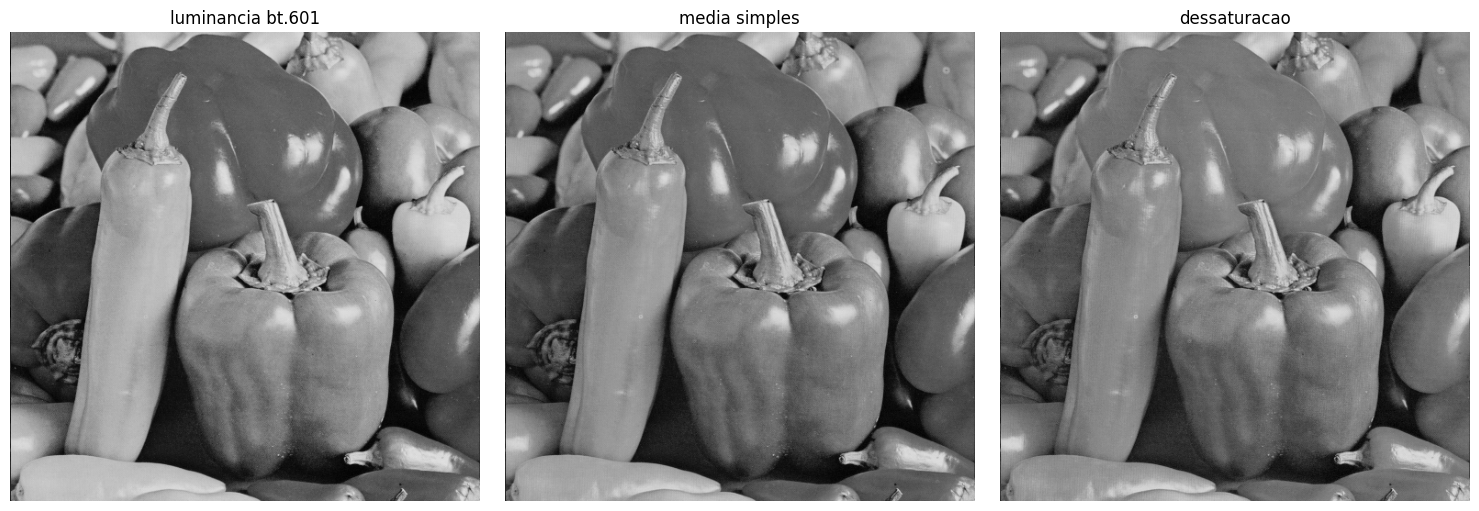

In [3]:
# converte a imagem de pimentoes de bgr para float em [0,1]
peppers = img_peppers_bgr.astype(np.float64) / 255.0  # normaliza para facilitar as formulas
# separa os canais respeitando a ordem b, g, r do cv2
B = peppers[:, :, 0]  # primeiro canal e o azul
G = peppers[:, :, 1]  # segundo canal e o verde
R = peppers[:, :, 2]  # terceiro canal e o vermelho

# metodo 1: luminancia bt.601 com pesos perceptuais por canal
gray_lum = 0.299 * R + 0.587 * G + 0.114 * B  # pondera mais o verde e menos o azul
# metodo 2: media aritmetica simples dos tres canais
gray_media = (R + G + B) / 3.0  # trata todos os canais com o mesmo peso
# metodo 3: dessaturacao pela media entre o maior e o menor canal de cada pixel
maxc = np.maximum(np.maximum(R, G), B)  # canal de maior valor por pixel
minc = np.minimum(np.minimum(R, G), B)  # canal de menor valor por pixel
gray_dessat = (maxc + minc) / 2.0  # ponto medio do intervalo de cor

# exibe as tres conversoes lado a lado para evidenciar que nao sao equivalentes
fig, ax = plt.subplots(1, 3, figsize=(15, 5))  # tres eixos na horizontal
ax[0].imshow(gray_lum, cmap="gray", vmin=0, vmax=1); ax[0].set_title("luminancia bt.601"); ax[0].axis("off")
ax[1].imshow(gray_media, cmap="gray", vmin=0, vmax=1); ax[1].set_title("media simples"); ax[1].axis("off")
ax[2].imshow(gray_dessat, cmap="gray", vmin=0, vmax=1); ax[2].set_title("dessaturacao"); ax[2].axis("off")
plt.tight_layout(); plt.show()  # ajusta o espacamento e exibe o painel


luminancia -> media=0.4715 mediana=0.4745 desvio=0.2113
media -> media=0.4339 mediana=0.4248 desvio=0.1785


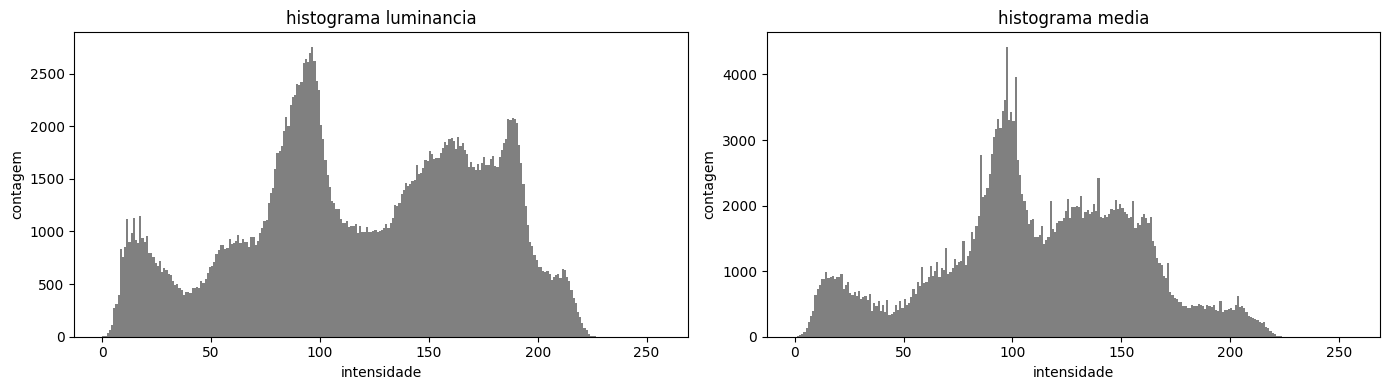

salvo q1_conversao_cinza.csv


In [4]:
# analise completa para dois metodos escolhidos: luminancia e media
# justificativa: a luminancia e o padrao perceptual; a media e a alternativa ingenua
# mais comum, entao comparar as duas mostra o erro perceptual de ignorar os pesos
metodos = {"luminancia": gray_lum, "media": gray_media}  # dicionario dos dois escolhidos

# monta os histogramas dos dois metodos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 4))  # dois eixos para os dois histogramas
linha_csv = []  # acumula estatisticas para salvar em csv
for i, (nome, im) in enumerate(metodos.items()):
    vals = (im * 255).astype(np.uint8).ravel()  # converte para 0..255 e lineariza
    ax[i].hist(vals, bins=256, range=(0, 256), color="gray")  # histograma de 256 bins
    ax[i].set_title("histograma " + nome)  # titulo identificando o metodo
    ax[i].set_xlabel("intensidade"); ax[i].set_ylabel("contagem")  # rotulos dos eixos
    # calcula estatisticas descritivas do metodo
    m, md_, s = im.mean(), np.median(im), im.std()  # media, mediana e desvio
    print(nome, "-> media=%.4f mediana=%.4f desvio=%.4f" % (m, md_, s))  # imprime
    linha_csv.append([nome, m, md_, s])  # guarda para o csv
plt.tight_layout(); plt.show()  # exibe os histogramas

# salva as estatisticas das conversoes em csv
with open("q1_conversao_cinza.csv", "w", newline="") as f:
    w = csv.writer(f)  # cria o escritor csv
    w.writerow(["metodo", "media", "mediana", "desvio"])  # cabecalho
    w.writerows(linha_csv)  # linhas de dados
print("salvo q1_conversao_cinza.csv")  # confirma a gravacao


**Discussão (1.2).** Os três métodos não produzem a mesma imagem porque tratam a cor de formas diferentes. A **luminância** pondera o verde (0,587) muito acima do azul (0,114), refletindo a sensibilidade do olho humano, então regiões verdes ficam mais claras e azuis mais escuras de forma perceptualmente coerente. A **média simples** dá o mesmo peso aos canais, o que clareia demais os azuis e escurece os verdes em relação ao esperado, achatando o contraste perceptual. A **dessaturação** depende apenas dos extremos (max e min) de cada pixel, ignorando o canal intermediário, o que tende a gerar tons médios e perder informação cromática. Numericamente isso aparece nas médias e desvios diferentes impressos acima. Lembramos que, por usar `cv2.imread` (BGR), atribuir os canais na ordem errada trocaria os pesos de R e B e corromperia a luminância.

## 1.3 Normalização em três faixas

Demonstramos numericamente (min, max, média e tipo antes/depois) em **uma** imagem cinza (a boat).

In [5]:
# usa a imagem boat (airplane2) em cinza para demonstrar as faixas de normalizacao
amostra = img_boat.copy()  # copia para nao alterar o original
# mostra estatisticas do dado original em uint8 (faixa 0..255)
print("original     -> dtype=%s min=%d max=%d media=%.2f" %
      (amostra.dtype, amostra.min(), amostra.max(), amostra.mean()))

# faixa 1: float em [0,1] dividindo por 255
norm01 = amostra.astype(np.float64) / 255.0  # mapeia 0..255 para 0..1
print("[0,1] float  -> dtype=%s min=%.3f max=%.3f media=%.3f" %
      (norm01.dtype, norm01.min(), norm01.max(), norm01.mean()))

# faixa 2: inteiro em [0,255] reescalando por min-max e voltando para uint8
mn, mx = amostra.min(), amostra.max()  # minimo e maximo reais da imagem
norm255 = ((amostra - mn) * 255.0 / (mx - mn)).astype(np.uint8)  # estica o contraste
print("[0,255] uint8-> dtype=%s min=%d max=%d media=%.2f" %
      (norm255.dtype, norm255.min(), norm255.max(), norm255.mean()))

# faixa 3: float em [-1,1] com media proxima de zero
norm11 = norm01 * 2.0 - 1.0  # desloca [0,1] para [-1,1]
print("[-1,1] float -> dtype=%s min=%.3f max=%.3f media=%.3f" %
      (norm11.dtype, norm11.min(), norm11.max(), norm11.mean()))


original     -> dtype=uint8 min=3 max=250 media=175.33
[0,1] float  -> dtype=float64 min=0.012 max=0.980 media=0.688
[0,255] uint8-> dtype=uint8 min=0 max=255 media=177.40
[-1,1] float -> dtype=float64 min=-0.976 max=0.961 media=0.375


**Discussão (1.3).** Cada faixa serve a um propósito. O intervalo **[0,1] em float** é o mais comum para processamento, pois evita estouro de inteiro nas contas (somas, multiplicações, log) e mantém precisão. O intervalo **[0,255] em uint8** é adequado para armazenar/exibir a imagem e quando se quer aproveitar o contraste total do display (a reescala min-max usada aqui aumenta o contraste). O intervalo **[-1,1] com média próxima de zero** é útil em métodos que esperam dados centrados (por exemplo entradas de algoritmos numéricos ou filtragens que assumem média nula), pois remove o nível DC e deixa o sinal simétrico em torno de zero.

## 1.4 Padding sem cv2.copyMakeBorder

Primeiro recortamos a boat de 512x512 para 500x500 (tamanho que não é potência de 2) e então implementamos o padding de volta até 512x512.

* **Obrigatórios:** zero-padding e reflexivo (espelhado).
* **Aprofundamento:** replicativo e periódico (wrap-around).

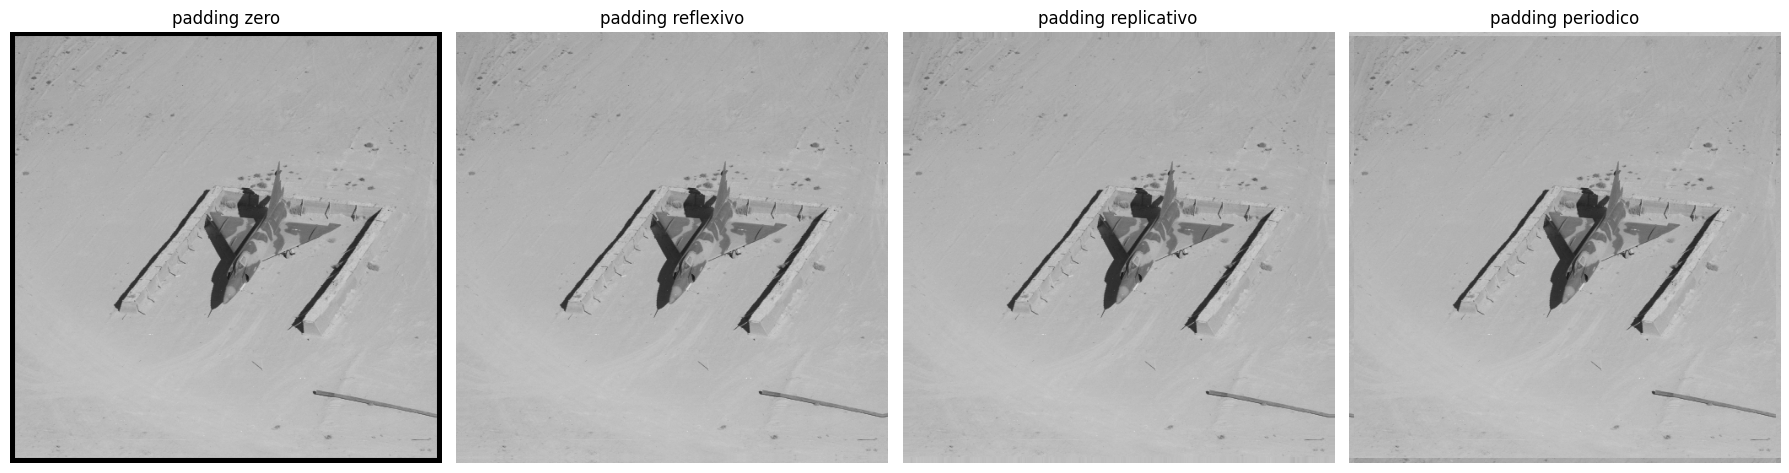

formatos: (512, 512) (512, 512) (512, 512) (512, 512)


In [6]:
# recorta a boat de 512x512 para 500x500 (tamanho que nao e potencia de 2)
recorte = img_boat[:500, :500].astype(np.float64)  # pega o canto superior esquerdo
alvo = 512  # tamanho final desejado apos o padding
falta = alvo - recorte.shape[0]  # quantas linhas/colunas faltam ao todo
antes = falta // 2  # metade do padding vai antes (topo/esquerda)
depois = falta - antes  # o restante vai depois (base/direita)

# zero-padding: cria uma matriz de zeros e insere o recorte no centro
zero_pad = np.zeros((alvo, alvo), dtype=np.float64)  # tela preta do tamanho final
zero_pad[antes:antes + 500, antes:antes + 500] = recorte  # cola o recorte centralizado

# padding reflexivo (espelhado) usando fatias invertidas sem repetir a borda
def pad_reflexivo(im, antes, depois):
    topo = im[1:antes + 1][::-1, :]  # reflete as linhas de cima (sem repetir a borda)
    base = im[-depois - 1:-1][::-1, :]  # reflete as linhas de baixo
    vert = np.vstack([topo, im, base])  # empilha verticalmente
    esq = vert[:, 1:antes + 1][:, ::-1]  # reflete as colunas da esquerda
    dire = vert[:, -depois - 1:-1][:, ::-1]  # reflete as colunas da direita
    return np.hstack([esq, vert, dire])  # concatena horizontalmente
refl_pad = pad_reflexivo(recorte, antes, depois)  # aplica o padding reflexivo

# padding replicativo: repete a linha/coluna da borda
def pad_replicativo(im, antes, depois):
    topo = np.repeat(im[:1, :], antes, axis=0)  # repete a primeira linha
    base = np.repeat(im[-1:, :], depois, axis=0)  # repete a ultima linha
    vert = np.vstack([topo, im, base])  # empilha verticalmente
    esq = np.repeat(vert[:, :1], antes, axis=1)  # repete a primeira coluna
    dire = np.repeat(vert[:, -1:], depois, axis=1)  # repete a ultima coluna
    return np.hstack([esq, vert, dire])  # concatena horizontalmente
rep_pad = pad_replicativo(recorte, antes, depois)  # aplica o padding replicativo

# padding periodico (wrap-around): indices circulares com modulo
def pad_periodico(im, antes, depois):
    h, w = im.shape  # dimensoes do recorte
    li = (np.arange(-antes, h + depois) % h)  # indices de linha que dao a volta
    ci = (np.arange(-antes, w + depois) % w)  # indices de coluna que dao a volta
    return im[np.ix_(li, ci)]  # seleciona com indexacao avancada
per_pad = pad_periodico(recorte, antes, depois)  # aplica o padding periodico

# exibe os quatro paddings em um painel para comparar os artefatos de borda
fig, ax = plt.subplots(1, 4, figsize=(18, 5))  # quatro eixos
for a, im, t in zip(ax, [zero_pad, refl_pad, rep_pad, per_pad],
                    ["zero", "reflexivo", "replicativo", "periodico"]):
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title("padding " + t); a.axis("off")
plt.tight_layout(); plt.show()  # exibe o painel
print("formatos:", zero_pad.shape, refl_pad.shape, rep_pad.shape, per_pad.shape)  # confere 512x512


**Discussão (1.4).** A FFT é mais eficiente quando o tamanho é potência de 2 porque o algoritmo de Cooley-Tukey divide recursivamente a transformada pela metade, atingindo custo $O(N\log N)$; tamanhos com fatores primos grandes (como 500) quebram essa recursão e caem para algoritmos mais lentos, por isso completar até 512 ajuda. Quanto aos artefatos de borda: o **zero-padding** insere uma descontinuidade abrupta (transição brusca para preto) que espalha energia em altas frequências e cria efeito de borda escura; o **reflexivo** e o **replicativo** suavizam essa transição (a borda continua de forma natural), reduzindo o vazamento espectral; o **periódico (wrap-around)** faz a imagem se repetir, conectando a borda direita com a esquerda. Conceitualmente o padding periódico corresponde exatamente à hipótese implícita da DFT: a convolução no domínio da frequência é **circular**, ou seja, a imagem é tratada como se fosse infinita e periódica. Por isso, quando não queremos esse efeito de "dar a volta", usamos zero-padding suficiente para transformar a convolução circular em convolução linear.

## 1.5 Histograma, histograma cumulativo, estatísticas e dispersão de vizinhos

media=175.33 mediana=180.00 desvio=22.12 assimetria=-3.986 curtose=18.570


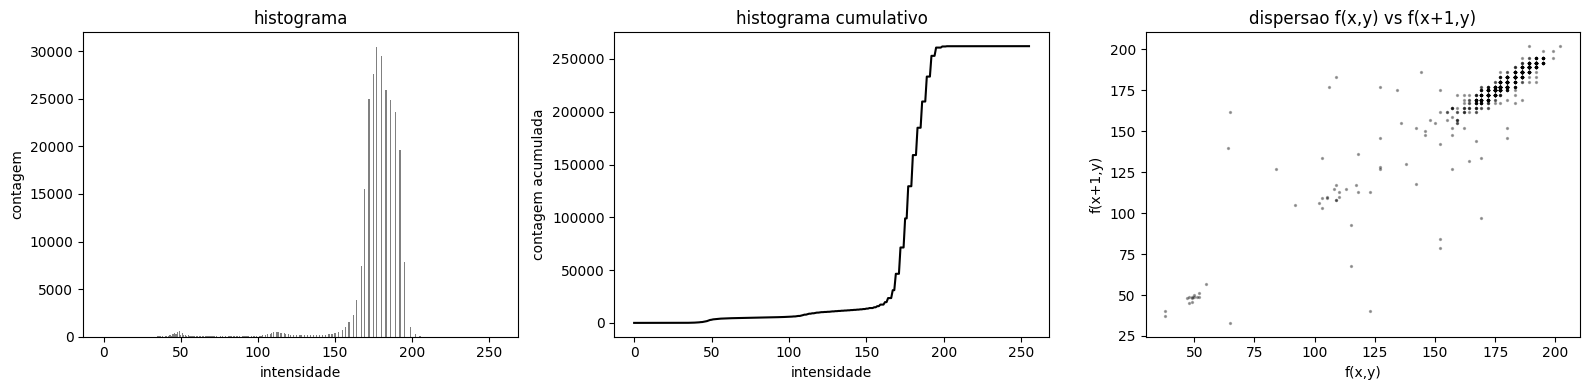

In [7]:
# usa a boat em cinza para a analise estatistica completa
g = img_boat.astype(np.float64)  # converte para float para as estatisticas
# histograma em 256 niveis (contagem de pixels por intensidade)
hist, _ = np.histogram(g, bins=256, range=(0, 256))  # vetor de contagens
# histograma cumulativo somando progressivamente as contagens
hist_cum = np.cumsum(hist)  # acumula da esquerda para a direita

# estatisticas descritivas: media, mediana, desvio, assimetria e curtose
media = g.mean(); mediana = np.median(g); desvio = g.std()  # tendencia central e dispersao
z = (g - media) / desvio  # variavel padronizada para os momentos de forma
skew = (z ** 3).mean()  # assimetria (terceiro momento padronizado)
curt = (z ** 4).mean() - 3.0  # curtose em excesso (quarto momento menos 3)
print("media=%.2f mediana=%.2f desvio=%.2f assimetria=%.3f curtose=%.3f" %
      (media, mediana, desvio, skew, curt))  # imprime as estatisticas

# painel com histograma, histograma cumulativo e dispersao de vizinhos
fig, ax = plt.subplots(1, 3, figsize=(16, 4))  # tres graficos lado a lado
ax[0].bar(np.arange(256), hist, color="gray"); ax[0].set_title("histograma")
ax[0].set_xlabel("intensidade"); ax[0].set_ylabel("contagem")
ax[1].plot(hist_cum, color="black"); ax[1].set_title("histograma cumulativo")
ax[1].set_xlabel("intensidade"); ax[1].set_ylabel("contagem acumulada")
# dispersao do pixel f(x,y) contra o vizinho a direita f(x+1,y), subamostrando 1 a cada 16
viz_x = g[:, :-1][::16, ::16].ravel()  # pixel atual subamostrado
viz_y = g[:, 1:][::16, ::16].ravel()  # vizinho a direita subamostrado
ax[2].scatter(viz_x, viz_y, s=2, alpha=0.3, color="black")  # nuvem de pontos
ax[2].set_title("dispersao f(x,y) vs f(x+1,y)")
ax[2].set_xlabel("f(x,y)"); ax[2].set_ylabel("f(x+1,y)")
plt.tight_layout(); plt.show()  # exibe o painel


**Leitura (1.5).** A forte correlação entre pixels vizinhos aparece como uma nuvem concentrada perto da diagonal $f(x,y)\approx f(x+1,y)$, confirmando a redundância espacial típica de imagens naturais. A assimetria e a curtose impressas resumem o formato do histograma (para que lado ele pende e o peso das caudas).

## 1.6 Equalização de histograma em Python puro

Usamos $s_k = (L-1)\sum_{j=0}^{k} \dfrac{n_j}{n}$, sem `cv2.equalizeHist`.

contraste rms antes=22.12 depois=74.88


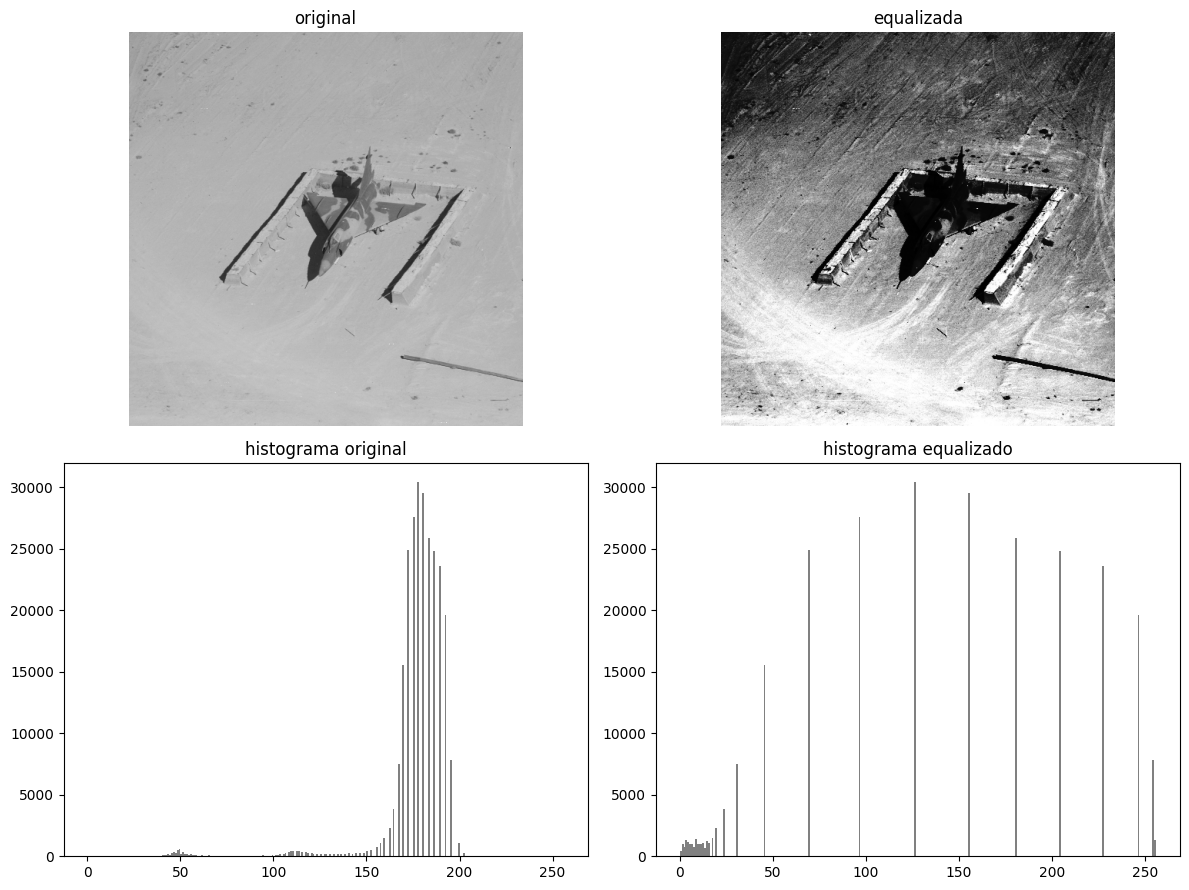

In [8]:
# equalizacao de histograma em python puro (sem cv2.equalizeHist)
def equaliza(im, L=256):
    im_u = im.astype(np.uint8)  # garante trabalho em 0..255
    n_j = np.bincount(im_u.ravel(), minlength=L)  # conta pixels por nivel de intensidade
    n = im_u.size  # numero total de pixels
    cdf = np.cumsum(n_j) / n  # soma acumulada das frequencias relativas (cdf)
    mapa = np.round((L - 1) * cdf).astype(np.uint8)  # aplica s_k = (L-1)*cdf e arredonda
    return mapa[im_u]  # remapeia cada pixel pela tabela construida
boat_eq = equaliza(img_boat)  # equaliza a imagem boat

# metrica de contraste rms (desvio padrao das intensidades) antes e depois
rms_antes = img_boat.astype(np.float64).std()  # contraste antes
rms_depois = boat_eq.astype(np.float64).std()  # contraste depois
print("contraste rms antes=%.2f depois=%.2f" % (rms_antes, rms_depois))  # compara

# painel: imagem e histograma antes e depois da equalizacao
fig, ax = plt.subplots(2, 2, figsize=(12, 9))  # grade 2x2
ax[0, 0].imshow(img_boat, cmap="gray", vmin=0, vmax=255); ax[0, 0].set_title("original"); ax[0, 0].axis("off")
ax[0, 1].imshow(boat_eq, cmap="gray", vmin=0, vmax=255); ax[0, 1].set_title("equalizada"); ax[0, 1].axis("off")
ax[1, 0].hist(img_boat.ravel(), bins=256, range=(0, 256), color="gray"); ax[1, 0].set_title("histograma original")
ax[1, 1].hist(boat_eq.ravel(), bins=256, range=(0, 256), color="gray"); ax[1, 1].set_title("histograma equalizado")
plt.tight_layout(); plt.show()  # exibe o painel


**Discussão (1.6).** A equalização redistribui as intensidades para aproximar um histograma uniforme, espalhando os níveis mais concentrados e geralmente aumentando o contraste global (visível no aumento do contraste RMS e no histograma mais espalhado). Ela **ajuda** quando a imagem tem baixo contraste e níveis concentrados numa faixa estreita. Ela **piora** quando a imagem já tem boa distribuição ou quando há grandes áreas uniformes (como o céu da `airplane2`): nesses casos a equalização amplifica ruído e pode criar transições artificiais e saturação em regiões lisas. Como `airplane2` tem um céu amplo e suave, parte do efeito aparece como realce de ruído nessa região, ilustrando bem o lado negativo do método.

# Questão 2: Transformada de Fourier e Análise Espectral (17 pts)

Imagem: `boat` (cinza 512x512, papel de `airplane2`).

## 2.1 Potências de 2 e eficiência da FFT (texto)

A FFT (algoritmo de Cooley-Tukey) fatora a DFT em transformadas menores. Quando $N$ é potência de 2, a divisão recursiva por 2 é perfeita e o custo cai de $O(N^2)$ (DFT direta) para $O(N\log N)$. Tamanhos com fatores primos grandes não permitem essa fatoração limpa e ficam mais lentos, por isso é comum completar a imagem até uma potência de 2. O **zero-padding** antes da FFT não cria informação nova: ele apenas **interpola** o espectro, ou seja, amostra a transformada de Fourier contínua em mais pontos (linhas de frequência mais densas), deixando o espectro visualmente mais suave sem aumentar a resolução real de frequência.

## 2.2 FFT 2D e cálculo explícito de magnitude, fase e potência

$$|F(u,v)| = \sqrt{\operatorname{Re}^2(F) + \operatorname{Im}^2(F)}, \quad \phi(u,v) = \operatorname{arctan2}(\operatorname{Im}(F), \operatorname{Re}(F)), \quad P(u,v) = |F(u,v)|^2$$

In [9]:
# calcula a transformada de fourier 2d da boat com numpy
F = np.fft.fft2(img_boat.astype(np.float64))  # fft2 retorna numeros complexos
re = F.real  # parte real do espectro
im_ = F.imag  # parte imaginaria do espectro
# magnitude calculada explicitamente como raiz da soma dos quadrados
magnitude = np.sqrt(re ** 2 + im_ ** 2)  # modulo do numero complexo
# fase calculada com arctan2 para tratar corretamente os quatro quadrantes
fase = np.arctan2(im_, re)  # angulo no intervalo (-pi, pi]
# espectro de potencia como o quadrado da magnitude
potencia = magnitude ** 2  # energia por componente de frequencia
print("magnitude min/max:", magnitude.min(), magnitude.max())  # confere a faixa
print("fase min/max:", fase.min(), fase.max())  # confere a faixa da fase


magnitude min/max: 1.9921106684073986 45963002.0
fase min/max: -3.1415853367250186 3.141592653589793


**Por que arctan2.** A função `np.arctan2(Im, Re)` recebe separadamente o numerador e o denominador e por isso identifica o **quadrante** correto do número complexo, devolvendo a fase em todo o intervalo $(-\pi, \pi]$. Já `arctan(Im/Re)` perderia o sinal e o quadrante (só cobre $(-\pi/2, \pi/2)$) e ainda estouraria quando $\operatorname{Re}=0$.

## 2.3 Visualização do espectro em escala logarítmica

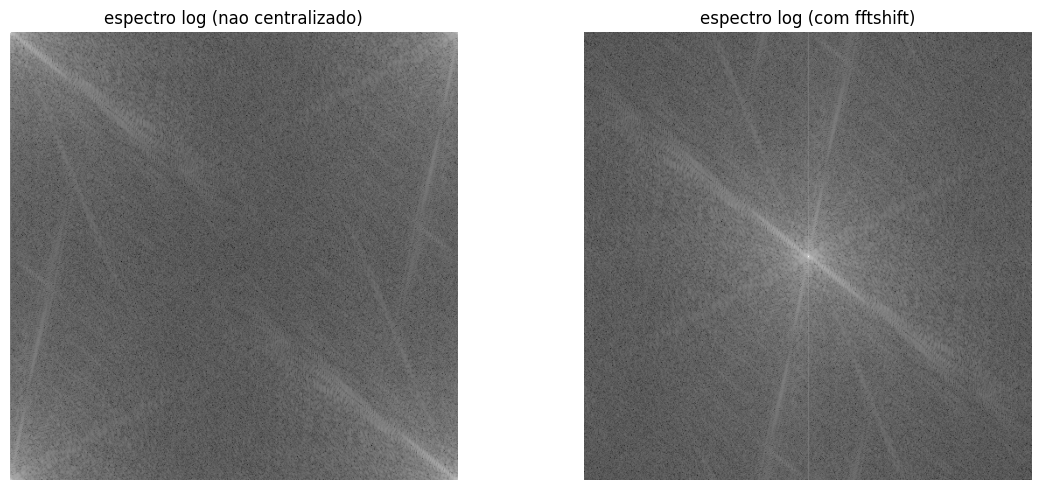

In [10]:
# espectro em escala log para comprimir a enorme faixa dinamica
S = np.log(1 + magnitude)  # log(1+|F|) realca componentes fracas
# espectro centralizado deslocando a frequencia zero para o centro
S_shift = np.log(1 + np.abs(np.fft.fftshift(F)))  # fftshift antes do log
# mostra o nao centralizado ao lado do centralizado
fig, ax = plt.subplots(1, 2, figsize=(12, 5))  # dois eixos
ax[0].imshow(S, cmap="gray"); ax[0].set_title("espectro log (nao centralizado)"); ax[0].axis("off")
ax[1].imshow(S_shift, cmap="gray"); ax[1].set_title("espectro log (com fftshift)"); ax[1].axis("off")
plt.tight_layout(); plt.show()  # exibe os espectros


## 2.4 Experimento de reconstrução (só magnitude vs só fase)

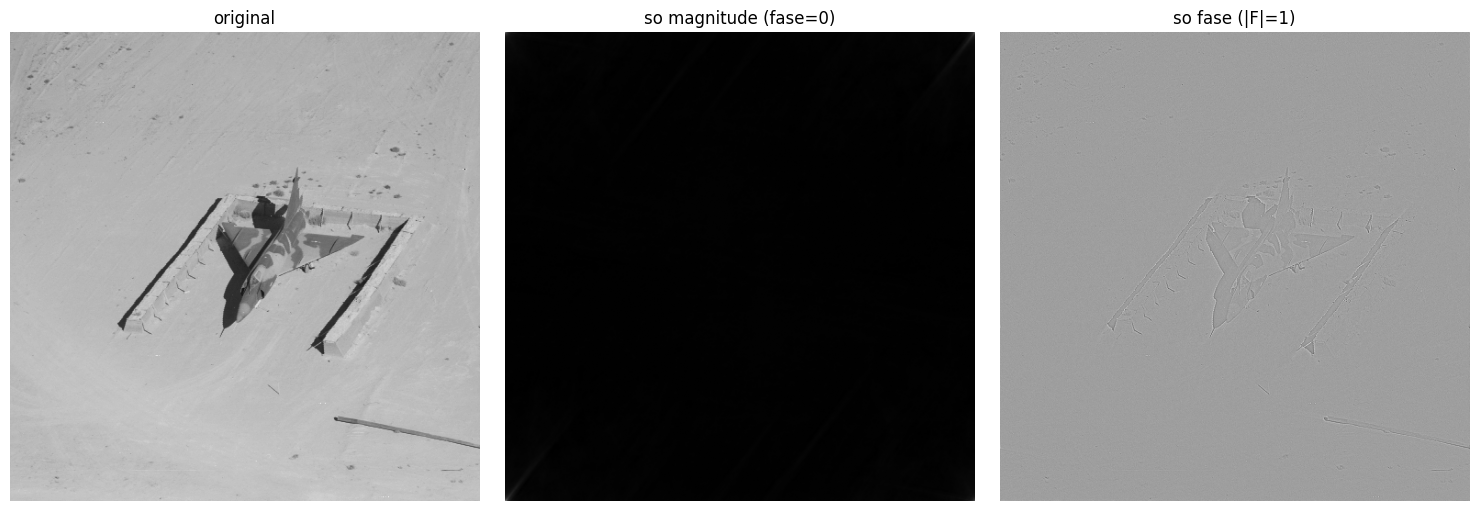

In [11]:
# reconstrucao usando apenas a magnitude (fase zerada)
F_mag = magnitude * np.exp(1j * 0.0)  # combina magnitude com fase nula
rec_mag = np.real(np.fft.ifft2(F_mag))  # volta ao dominio espacial
# reconstrucao usando apenas a fase (magnitude constante igual a 1)
F_fase = 1.0 * np.exp(1j * fase)  # combina magnitude unitaria com a fase original
rec_fase = np.real(np.fft.ifft2(F_fase))  # volta ao dominio espacial

# normaliza apenas para visualizar (reescala linear para 0..1)
def normaliza_vis(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)  # min-max para exibicao

# painel comparando original, so magnitude e so fase
fig, ax = plt.subplots(1, 3, figsize=(15, 5))  # tres eixos
ax[0].imshow(img_boat, cmap="gray"); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(normaliza_vis(rec_mag), cmap="gray"); ax[1].set_title("so magnitude (fase=0)"); ax[1].axis("off")
ax[2].imshow(normaliza_vis(rec_fase), cmap="gray"); ax[2].set_title("so fase (|F|=1)"); ax[2].axis("off")
plt.tight_layout(); plt.show()  # exibe o painel


**Explicação (2.4).** A reconstrução só com magnitude perde toda a estrutura espacial e vira um borrão sem forma reconhecível, enquanto a reconstrução só com a fase ainda revela os contornos e a organização da cena. Isso mostra que a **fase carrega a informação de posição das estruturas** (bordas, objetos), sendo perceptualmente mais importante que a magnitude, que guarda apenas o quanto de cada frequência existe.

## 2.5 Padrões no espectro e simetria conjugada

In [12]:
# verifica numericamente a simetria conjugada F(u,v) = conj(F(-u,-v)) para imagem real
F2 = np.fft.fft2(img_boat.astype(np.float64))  # recalcula a fft
# constroi F(-u,-v) invertendo os indices de forma circular
F_inv = np.conj(np.fft.fft2(img_boat.astype(np.float64))[::-1, ::-1])  # conjugado do espelhado
# desloca uma linha/coluna porque o indice 0 nao tem par simetrico ao inverter
F_inv = np.roll(np.roll(F_inv, 1, axis=0), 1, axis=1)  # alinha os indices simetricos
erro = np.max(np.abs(F2 - F_inv))  # diferenca maxima entre os dois lados
print("erro maximo da simetria conjugada:", erro)  # deve ser proximo de zero


erro maximo da simetria conjugada: 3.2927225399135965e-10


**Padrões (2.5).** No espectro centralizado a energia se concentra no centro (baixas frequências), pois imagens naturais são dominadas por variações suaves. As **linhas** que cruzam o centro correspondem a bordas e estruturas orientadas: uma borda em certa direção gera energia na direção perpendicular do espectro. Por a imagem ser real, vale a **simetria conjugada** $F(u,v)=F^*(-u,-v)$, confirmada acima pelo erro próximo de zero (a menos de erro numérico), o que torna o espectro de magnitude simétrico em relação ao centro.

## 2.6 (Aprof.) Espectro radial médio

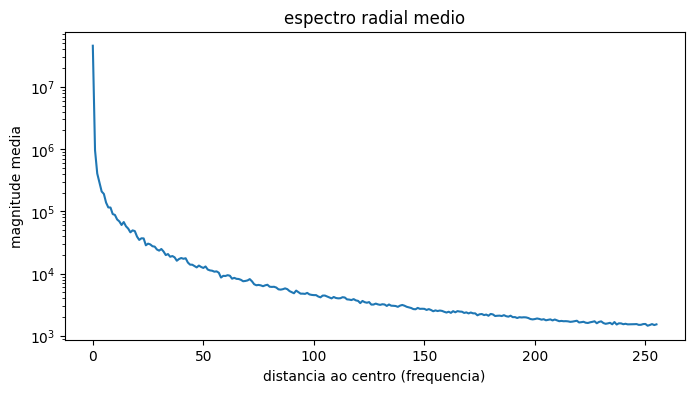

In [13]:
# espectro radial medio: perfil 1d da magnitude em funcao da distancia ao centro
Mag_c = np.fft.fftshift(magnitude)  # centraliza a magnitude
M, N = Mag_c.shape  # dimensoes do espectro
yy, xx = np.indices((M, N))  # grades de indices de linha e coluna
r = np.sqrt((xx - N / 2) ** 2 + (yy - M / 2) ** 2).astype(np.int32)  # distancia inteira ao centro
soma = np.bincount(r.ravel(), weights=Mag_c.ravel())  # soma a magnitude por anel radial
cont = np.bincount(r.ravel())  # numero de pixels por anel
perfil = soma / np.maximum(cont, 1)  # media radial evitando divisao por zero
plt.figure(figsize=(8, 4))  # cria a figura
plt.semilogy(perfil[:M // 2])  # plota em escala log no eixo y
plt.title("espectro radial medio"); plt.xlabel("distancia ao centro (frequencia)")
plt.ylabel("magnitude media"); plt.show()  # exibe o perfil


**Leitura (2.6).** O perfil radial decai rápido do centro para fora, confirmando que a maior parte da energia está nas baixas frequências. A cauda em altas frequências indica o quanto de detalhe fino a imagem tem; como usamos `airplane2` (cena suave), essa cauda é relativamente baixa, o que já antecipa que filtros passa-baixa preservarão quase toda a aparência da imagem.

## 2.7 Discussão integrada

(i) A **escala logarítmica** é necessária porque a componente DC (centro) é ordens de grandeza maior que as demais; sem o log só o ponto central apareceria e o resto ficaria preto. (ii) Após o **fftshift**, as **baixas frequências ficam no centro** e as **altas nas bordas** da imagem espectral, o que torna a interpretação intuitiva. (iii) Esse alinhamento importa nas Questões 3 e 4 porque construímos os filtros $H(u,v)$ centrados (distância medida a partir do centro); para multiplicar filtro e espectro corretamente eles precisam estar no mesmo referencial, por isso aplicamos `fftshift` no espectro antes de filtrar e `ifftshift` antes da transformada inversa.

# Questão 3: Filtragem no Domínio da Frequência (20 pts)

Imagem: a mesma da Q2 (`boat`/`airplane2`).

## 3.1 Filtros Gaussianos passa-baixa e passa-alta (e passa-faixa, aprof.)

$$H_{PB}=e^{-D^2/2\sigma^2}, \quad H_{PA}=1-e^{-D^2/2\sigma^2}, \quad H_{PF}=e^{-(D-D_0)^2/2W^2}$$

com $D(u,v)=\sqrt{(u-M/2)^2+(v-N/2)^2}$. Todos os filtros são construídos em NumPy, com alinhamento via `fftshift`/`ifftshift`.

In [14]:
# grade de distancias d(u,v) ao centro do espectro (frequencia zero centralizada)
def grade_distancia(shape):
    M, N = shape  # dimensoes da imagem
    u = np.arange(M).reshape(-1, 1)  # indices de linha como coluna
    v = np.arange(N).reshape(1, -1)  # indices de coluna como linha
    return np.sqrt((u - M / 2) ** 2 + (v - N / 2) ** 2)  # distancia euclidiana ao centro

# filtro gaussiano passa-baixa (atenua altas frequencias)
def filtro_pb(shape, sigma):
    D = grade_distancia(shape)  # distancias ao centro
    return np.exp(-(D ** 2) / (2.0 * sigma ** 2))  # gaussiana

# filtro gaussiano passa-alta (complemento do passa-baixa)
def filtro_pa(shape, sigma):
    return 1.0 - filtro_pb(shape, sigma)  # deixa passar altas frequencias

# filtro gaussiano passa-faixa centrado em d0 com largura w
def filtro_pf(shape, D0, W):
    D = grade_distancia(shape)  # distancias ao centro
    return np.exp(-((D - D0) ** 2) / (2.0 * W ** 2))  # realca um anel de frequencias

# aplica um filtro centralizado via fft, multiplicacao e ifft (com alinhamento)
def aplica_filtro_freq(im, H):
    F = np.fft.fftshift(np.fft.fft2(im.astype(np.float64)))  # leva ao dominio centralizado
    G = H * F  # multiplica espectro pelo filtro no mesmo referencial
    g = np.real(np.fft.ifft2(np.fft.ifftshift(G)))  # desfaz o shift e volta ao espaco
    return g


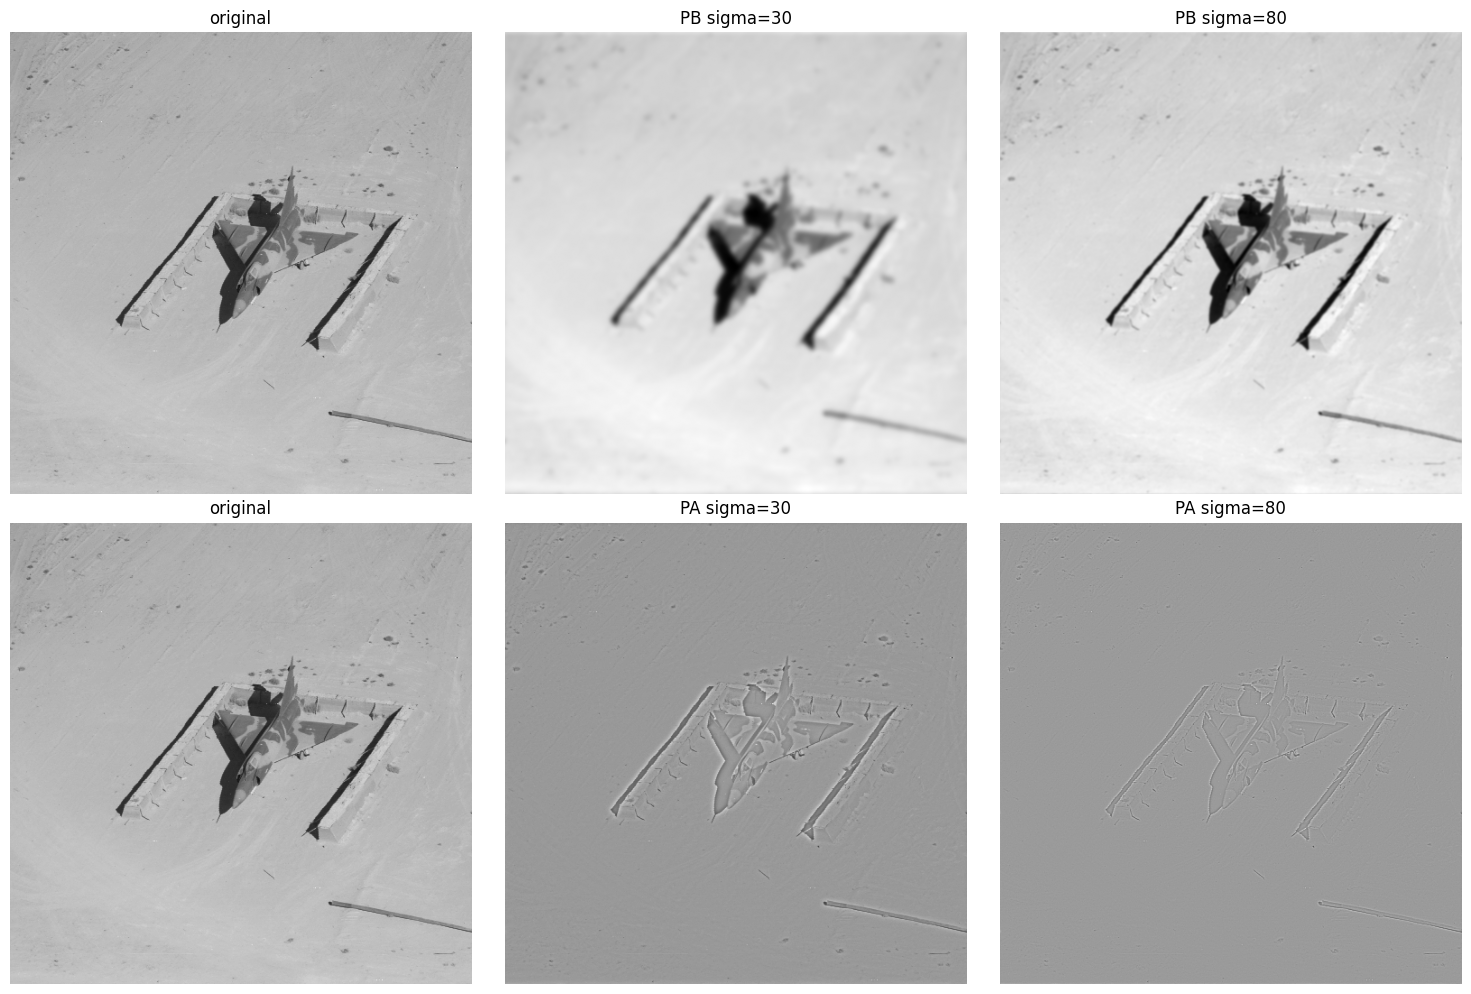

In [15]:
# testa o passa-baixa e o passa-alta com dois valores de sigma cada
shape = img_boat.shape  # dimensoes da imagem de trabalho
sigmas = [30, 80]  # dois valores de sigma exigidos
fig, ax = plt.subplots(2, 3, figsize=(15, 10))  # grade 2x3 (linha pb e linha pa)
ax[0, 0].imshow(img_boat, cmap="gray"); ax[0, 0].set_title("original"); ax[0, 0].axis("off")
ax[1, 0].imshow(img_boat, cmap="gray"); ax[1, 0].set_title("original"); ax[1, 0].axis("off")
for j, s in enumerate(sigmas):
    pb = aplica_filtro_freq(img_boat, filtro_pb(shape, s))  # passa-baixa
    pa = aplica_filtro_freq(img_boat, filtro_pa(shape, s))  # passa-alta
    ax[0, j + 1].imshow(np.clip(pb, 0, 255), cmap="gray"); ax[0, j + 1].set_title("PB sigma=%d" % s); ax[0, j + 1].axis("off")
    ax[1, j + 1].imshow(normaliza_vis(pa), cmap="gray"); ax[1, j + 1].set_title("PA sigma=%d" % s); ax[1, j + 1].axis("off")
plt.tight_layout(); plt.show()  # exibe o painel


**Leitura (3.1).** O passa-baixa borra a imagem (remove detalhes finos) e o efeito é mais forte para $\sigma$ menor (corte mais agressivo). O passa-alta realça bordas e suprime as regiões lisas, deixando o fundo escuro.

## 3.2 Ruído periódico multicomponente

$$f_{ruido}(x,y)=f(x,y)+A_1\sin\!\Big(\tfrac{2\pi u_1 x}{M}\Big)+A_2\cos\!\Big(\tfrac{2\pi v_1 y}{N}\Big)+A_3\sin\!\Big(\tfrac{2\pi u_2 x}{M}+\tfrac{2\pi v_2 y}{N}\Big)$$

com $A_1=60, A_2=45, A_3=55$, $(u_1,v_1)=(35,50)$, $(u_2,v_2)=(70,25)$. Os dois primeiros termos são senoides de eixo único (um em $x$, outro em $y$), então $(u_1,v_1)$ não formam um pico 2D conjunto; apenas o terceiro termo é uma senoide 2D.

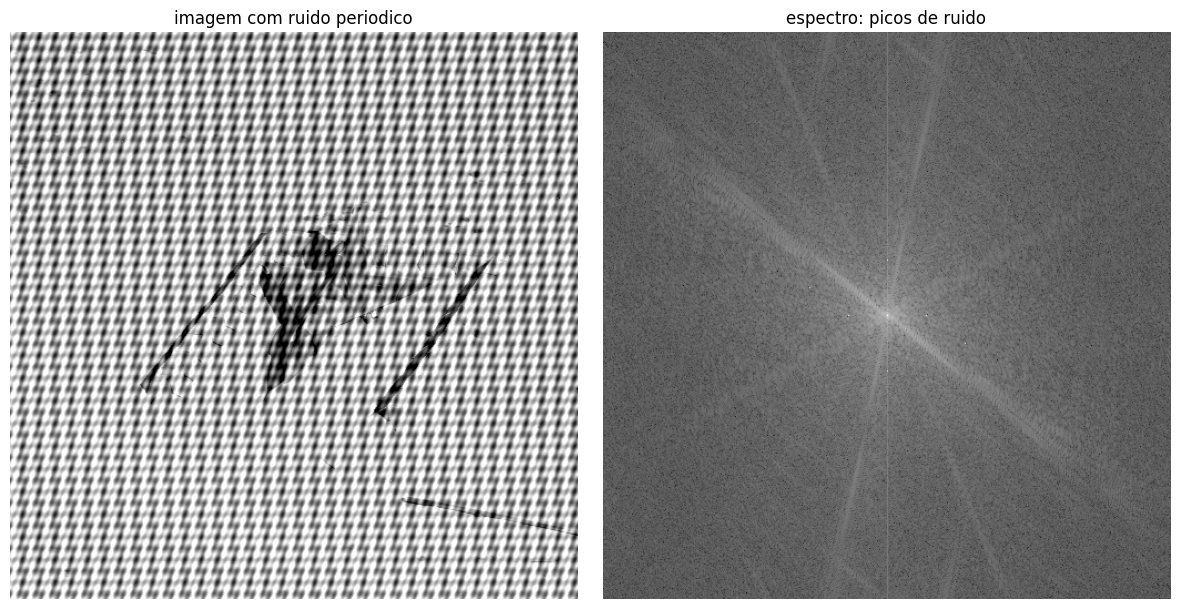

In [16]:
# converte a boat para float para somar o ruido sem estouro de uint8
f_orig = img_boat.astype(np.float64)  # referencia limpa em float
M, N = f_orig.shape  # dimensoes da imagem
y_idx, x_idx = np.indices((M, N))  # x_idx varia nas colunas, y_idx nas linhas

# amplitudes e frequencias do ruido periodico multicomponente
A1, A2, A3 = 60.0, 45.0, 55.0  # amplitudes dos tres termos
u1, v1 = 35, 50  # frequencias dos dois primeiros termos (eixo unico)
u2, v2 = 70, 25  # frequencias do terceiro termo (senoide 2d)

# primeiro termo: senoide apenas em x (colunas) com frequencia u1
ruido = A1 * np.sin(2 * np.pi * u1 * x_idx / M)
# segundo termo: cossenoide apenas em y (linhas) com frequencia v1
ruido = ruido + A2 * np.cos(2 * np.pi * v1 * y_idx / N)
# terceiro termo: senoide 2d combinando frequencias em x e y
ruido = ruido + A3 * np.sin(2 * np.pi * u2 * x_idx / M + 2 * np.pi * v2 * y_idx / N)

# soma o ruido a imagem e limita a faixa valida 0..255
f_ruido = f_orig + ruido  # imagem corrompida em float
f_ruido_u8 = np.clip(f_ruido, 0, 255).astype(np.uint8)  # volta para uint8 com clip

# espectro log centralizado da imagem corrompida para localizar os picos
Frui = np.fft.fftshift(np.fft.fft2(f_ruido))  # fft centralizada do ruidoso
Srui = np.log(1 + np.abs(Frui))  # espectro em escala log

# exibe a imagem corrompida e seu espectro com os picos de ruido
fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # dois eixos
ax[0].imshow(f_ruido_u8, cmap="gray"); ax[0].set_title("imagem com ruido periodico"); ax[0].axis("off")
ax[1].imshow(Srui, cmap="gray"); ax[1].set_title("espectro: picos de ruido"); ax[1].axis("off")
plt.tight_layout(); plt.show()  # exibe o painel


**Identificação dos picos.** Como a imagem é 512x512 ($M=N$), cada senoide gera impulsos simétricos no espectro centralizado. O termo em $x$ ($u_1=35$) gera picos em $(\text{centro}, \pm 35)$; o termo em $y$ ($v_1=50$) gera picos em $(\pm 50, \text{centro})$; a senoide 2D gera picos em $(\pm 25, \pm 70)$. Esses são os deslocamentos (linha, coluna) em relação ao centro usados no filtro notch.

## 3.3 Filtro rejeita-faixa Gaussiano (notch) na forma de produto

$$H_{notch}(u,v)=\prod_{k=1}^{K}\Big[1-e^{-D_k^{+2}/2D_0^2}\Big]\Big[1-e^{-D_k^{-2}/2D_0^2}\Big], \quad D_0=8$$

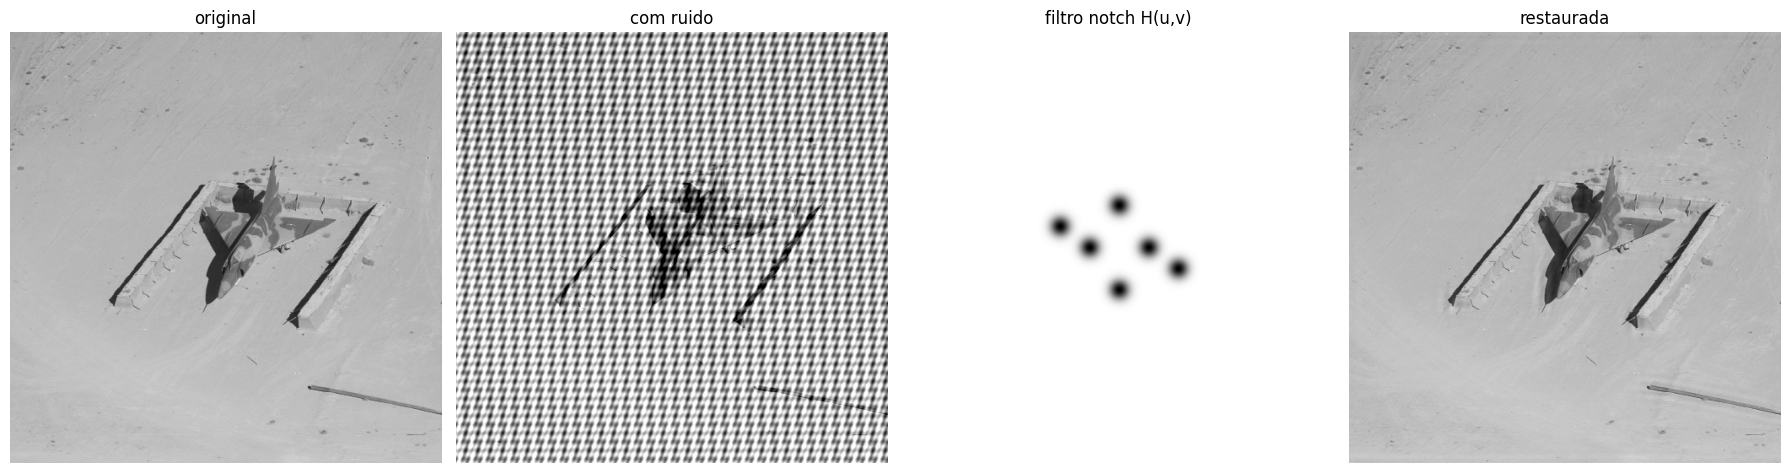

In [17]:
# filtro notch (rejeita-faixa) gaussiano no formato de produto para varios picos
def filtro_notch(shape, picos, D0=8.0):
    M, N = shape  # dimensoes
    u = np.arange(M).reshape(-1, 1)  # indices de linha
    v = np.arange(N).reshape(1, -1)  # indices de coluna
    cy, cx = M / 2, N / 2  # centro do espectro
    H = np.ones(shape, dtype=np.float64)  # comeca como identidade (deixa tudo passar)
    for (dy, dx) in picos:  # para cada pico e seu conjugado
        Dp = np.sqrt((u - (cy + dy)) ** 2 + (v - (cx + dx)) ** 2)  # distancia ao pico positivo
        Dm = np.sqrt((u - (cy - dy)) ** 2 + (v - (cx - dx)) ** 2)  # distancia ao pico simetrico
        # cada fator tende a 0 sobre o pico (rejeicao) e a 1 longe dele
        H = H * (1 - np.exp(-(Dp ** 2) / (2 * D0 ** 2))) * (1 - np.exp(-(Dm ** 2) / (2 * D0 ** 2)))
    return H

# deslocamentos (linha, coluna) dos picos em relacao ao centro
picos_ruido = [(0, 35), (50, 0), (25, 70)]  # termos 1, 2 e 3 do ruido
H_notch = filtro_notch(shape, picos_ruido, D0=8.0)  # monta o filtro notch

# aplica o notch a imagem corrompida para remover o ruido
rec_notch = aplica_filtro_freq(f_ruido, H_notch)  # imagem restaurada
rec_notch_u8 = np.clip(rec_notch, 0, 255).astype(np.uint8)  # volta para uint8

# painel: original, corrompida, filtro notch e restaurada
fig, ax = plt.subplots(1, 4, figsize=(18, 5))  # quatro eixos
ax[0].imshow(f_orig, cmap="gray"); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(f_ruido_u8, cmap="gray"); ax[1].set_title("com ruido"); ax[1].axis("off")
ax[2].imshow(H_notch, cmap="gray"); ax[2].set_title("filtro notch H(u,v)"); ax[2].axis("off")
ax[3].imshow(rec_notch_u8, cmap="gray"); ax[3].set_title("restaurada"); ax[3].axis("off")
plt.tight_layout(); plt.show()  # exibe o painel


## 3.4 Visualizações dos filtros (heatmap, dB e superfície 3D)

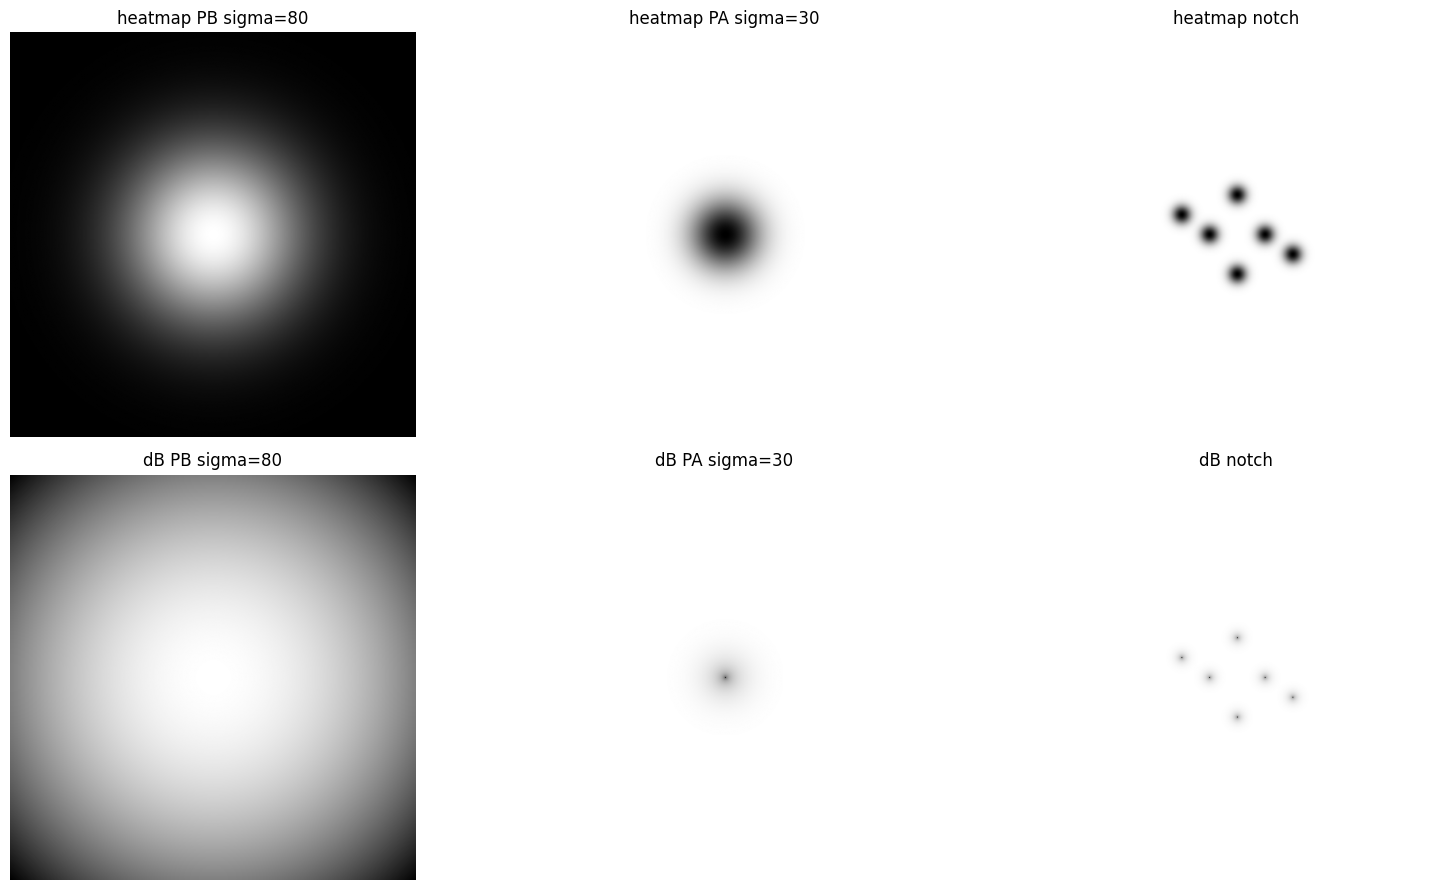

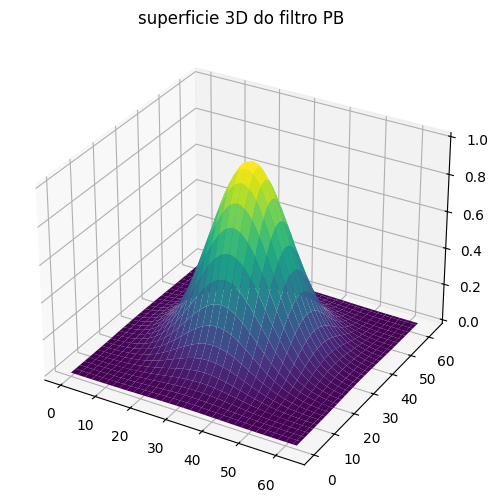

In [18]:
# prepara tres filtros do nucleo para visualizar
H_pb = filtro_pb(shape, 80)  # passa-baixa
H_pa = filtro_pa(shape, 30)  # passa-alta
filtros_vis = {"PB sigma=80": H_pb, "PA sigma=30": H_pa, "notch": H_notch}  # dicionario

# heatmap e modulo em dB de cada filtro
fig, ax = plt.subplots(2, 3, figsize=(16, 9))  # grade 2x3
for j, (nome, H) in enumerate(filtros_vis.items()):
    ax[0, j].imshow(H, cmap="gray"); ax[0, j].set_title("heatmap " + nome); ax[0, j].axis("off")
    # modulo em decibeis 20*log10|H| (soma epsilon para evitar log de zero)
    Hdb = 20 * np.log10(np.abs(H) + 1e-6)  # converte para db
    ax[1, j].imshow(Hdb, cmap="gray"); ax[1, j].set_title("dB " + nome); ax[1, j].axis("off")
plt.tight_layout(); plt.show()  # exibe as duas visualizacoes

# superficie 3d do passa-baixa (subamostrada para ficar leve)
passo = 8  # fator de subamostragem da malha 3d
Hs = H_pb[::passo, ::passo]  # filtro reduzido
yy3, xx3 = np.indices(Hs.shape)  # grade da malha reduzida
fig = plt.figure(figsize=(8, 6))  # figura 3d
ax3 = fig.add_subplot(projection="3d")  # eixo com projecao 3d
ax3.plot_surface(xx3, yy3, Hs, cmap="viridis")  # superficie do filtro
ax3.set_title("superficie 3D do filtro PB"); plt.show()  # exibe a superficie


## 3.5 Métricas de qualidade após remoção do ruído (MSE, PSNR, SNR)

In [19]:
# erro quadratico medio entre referencia e imagem processada
def mse(ref, x):
    return np.mean((ref.astype(np.float64) - x.astype(np.float64)) ** 2)  # media dos erros ao quadrado

# psnr em decibeis a partir do mse (valor maximo 255)
def psnr(ref, x):
    e = mse(ref, x)  # erro quadratico medio
    if e == 0:  # imagens identicas
        return float("inf")  # psnr infinito
    return 10 * np.log10((255.0 ** 2) / e)  # formula padrao

# relacao sinal-ruido como razao de energias em db
def snr(ref, x):
    ref = ref.astype(np.float64); x = x.astype(np.float64)  # garante float
    sig = np.sum(ref ** 2)  # energia do sinal de referencia
    ru = np.sum((ref - x) ** 2)  # energia do erro
    return 10 * np.log10(sig / ru)  # snr em decibeis

# metricas da imagem corrompida e da imagem restaurada pelo notch
print("ruidosa   -> MSE=%.2f PSNR=%.2f dB SNR=%.2f dB" %
      (mse(f_orig, f_ruido_u8), psnr(f_orig, f_ruido_u8), snr(f_orig, f_ruido_u8)))
print("notch     -> MSE=%.2f PSNR=%.2f dB SNR=%.2f dB" %
      (mse(f_orig, rec_notch_u8), psnr(f_orig, rec_notch_u8), snr(f_orig, rec_notch_u8)))


ruidosa   -> MSE=3521.68 PSNR=12.66 dB SNR=9.48 dB
notch     -> MSE=3.88 PSNR=42.24 dB SNR=39.05 dB


**Leitura (3.5).** Como existe uma **referência limpa** (a imagem antes do ruído sintético), o PSNR e o SNR são válidos: a imagem restaurada pelo notch deve apresentar PSNR e SNR maiores e MSE menor que a corrompida, confirmando a remoção do ruído periódico.

## 3.6 (Aprof.) Filtros Butterworth passa-baixa e o efeito de ringing

$$H_{BW}(u,v)=\frac{1}{1+\big(D(u,v)/D_0\big)^{2n}}, \quad n\in\{1,2,4\}, \; D_0=50$$

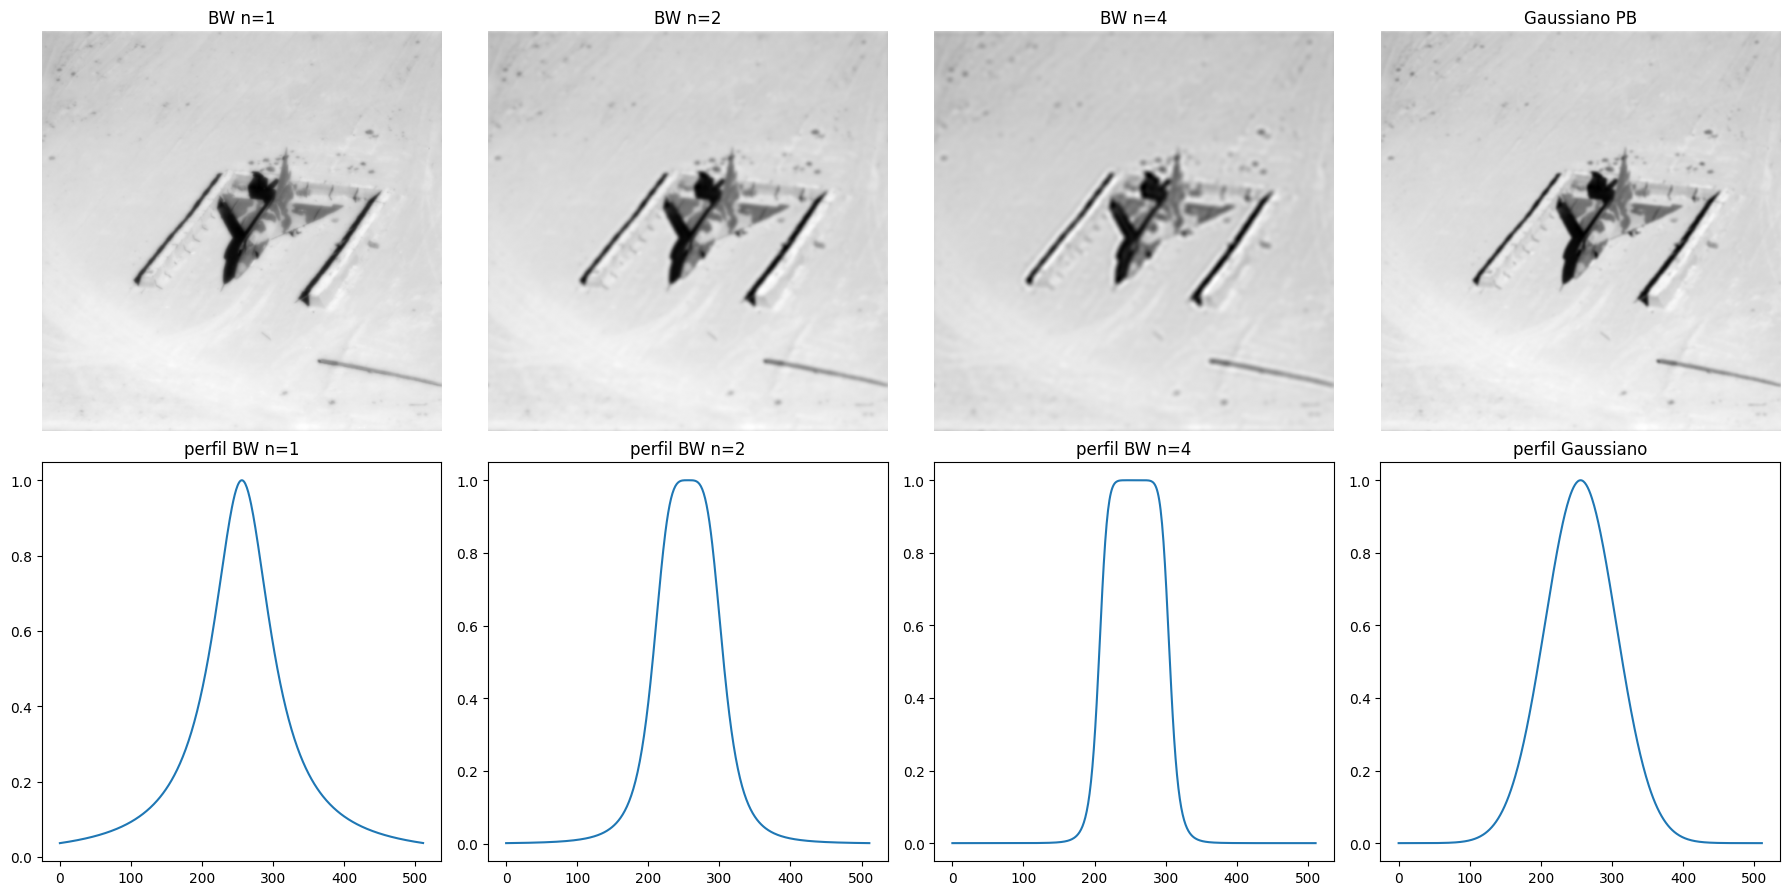

In [20]:
# filtro butterworth passa-baixa de ordem n
def filtro_butterworth(shape, D0, n):
    D = grade_distancia(shape)  # distancias ao centro
    return 1.0 / (1.0 + (D / D0) ** (2 * n))  # transicao controlada pela ordem n

# compara butterworth de ordens 1, 2 e 4 com o gaussiano pb (mesmo D0)
ordens = [1, 2, 4]  # ordens testadas
fig, ax = plt.subplots(2, 4, figsize=(18, 9))  # grade 2x4
# perfil radial 1d (linha central) para comparar a transicao dos filtros
centro = M // 2  # linha central do filtro
for j, n in enumerate(ordens):
    Hbw = filtro_butterworth(shape, 50, n)  # filtro butterworth
    res = aplica_filtro_freq(img_boat, Hbw)  # aplica a imagem
    ax[0, j].imshow(np.clip(res, 0, 255), cmap="gray"); ax[0, j].set_title("BW n=%d" % n); ax[0, j].axis("off")
    ax[1, j].plot(Hbw[centro, :]); ax[1, j].set_title("perfil BW n=%d" % n)  # perfil radial
# ultima coluna: gaussiano pb com D0=50 (sigma=50) para referencia
Hg = filtro_pb(shape, 50)  # gaussiano com sigma equivalente
resg = aplica_filtro_freq(img_boat, Hg)  # aplica
ax[0, 3].imshow(np.clip(resg, 0, 255), cmap="gray"); ax[0, 3].set_title("Gaussiano PB"); ax[0, 3].axis("off")
ax[1, 3].plot(Hg[centro, :]); ax[1, 3].set_title("perfil Gaussiano")  # perfil do gaussiano
plt.tight_layout(); plt.show()  # exibe o painel


**Discussão (3.6).** O Butterworth tem transição mais abrupta conforme a ordem $n$ cresce, aproximando-se de um corte ideal. Essa transição brusca introduz **ringing** (ondulações/halos perto das bordas), visível sobretudo em $n=4$, porque corta as frequências de forma quase descontínua. O Gaussiano, por não ter essa descontinuidade, não produz ringing, ao custo de um borramento mais suave e gradual.

# Questão 4: Auditoria de IA e Filtragem (30 pts + bônus)

## Parte A: Auditoria (a habilidade central desta questão)

Código gerado por IA para filtragem homomórfica (com três erros plantados):

```python
1  import cv2
2  import numpy as np
3
4  def homomorfico(caminho, gamma_l, gamma_h, c, d0, eps=0.01):
5      # 1) Leitura e conversao para cinza
6      img = cv2.imread(caminho)                       # imagem lida pelo OpenCV
7      R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]
8      Y = 0.299 * R + 0.587 * G + 0.114 * B           # luminancia
9      Y = Y / 255.0                                   # normaliza para [0, 1]
10
11     # 2) Dominio logaritmico
12     g = np.log(Y)
13
14     # 3) Transformada de Fourier
15     G_uv = np.fft.fft2(g)
16
17     # 4) Filtro homomorfico centrado em (M/2, N/2)
18     M, N = Y.shape
19     u = np.arange(M).reshape(-1, 1)
20     v = np.arange(N).reshape(1, -1)
21     D2 = (u - M / 2) ** 2 + (v - N / 2) ** 2
22     H = (gamma_h - gamma_l) * (1 - np.exp(-c * D2 / (d0 ** 2))) + gamma_l
23
24     # 5) Aplica o filtro e retorna ao dominio espacial
25     S = H * G_uv
26     s = np.real(np.fft.ifft2(S))
27     out = np.exp(s) - eps
28     return out
```

### (a) Os três erros e suas linhas

1. **Linha 7, ordem dos canais (BGR vs RGB).** O `cv2.imread` carrega a imagem em **BGR**, logo `img[:,:,0]` é o canal **azul**, não o vermelho. Atribuir `R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]` troca R por B na fórmula de luminância.

2. **Linha 12, log sem epsilon.** `g = np.log(Y)` calcula o logaritmo de zero quando há pixel preto ($Y=0$), gerando $-\infty$ e contaminando toda a FFT. Falta somar o epsilon: `np.log(Y + eps)`.

3. **Linha 15/22, alinhamento (falta de fftshift).** O filtro `H` é construído **centrado** em $(M/2, N/2)$, mas `G_uv = np.fft.fft2(g)` tem a frequência zero **no canto** (não foi centralizado). Filtro e espectro ficam desalinhados; é preciso `fftshift` no espectro e `ifftshift` antes da inversa.

### (b) Por que cada erro quebra o resultado

1. Trocar R por B aplica os pesos perceptuais nos canais errados, distorcendo a luminância (cores ficam com brilho incorreto). Em imagem realmente cinza o efeito é nulo, mas conceitualmente a fórmula está errada.

2. $\log(0)=-\infty$ propaga `-inf`/`nan` pela FFT e destrói a imagem de saída; o $\epsilon$ garante que o argumento do log seja sempre positivo. Além disso, o `out = exp(s) - eps` da linha 27 só é coerente se o log tiver sido `log(Y + eps)`.

3. Sem o `fftshift`, o filtro centrado multiplica o espectro na posição errada: o que deveria atenuar baixas frequências acaba atuando sobre altas (e vice-versa), invertendo o efeito do realce e gerando artefatos.

### (c) Função corrigida e demonstração com a cameraman (abaixo).

In [21]:
# versao corrigida da funcao homomorfica (corrige os tres erros)
def homomorfico_corrigido(caminho, gamma_l, gamma_h, c, d0, eps=0.01):
    img = cv2.imread(caminho)  # le a imagem (cv2 entrega em bgr)
    # correcao 1: respeita a ordem bgr ao separar os canais
    B, G, R = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    Y = 0.299 * R + 0.587 * G + 0.114 * B  # luminancia com canais corretos
    Y = Y / 255.0  # normaliza para [0,1]
    # correcao 2: soma eps antes do log para evitar log(0) = -inf
    g = np.log(Y + eps)
    # correcao 3: centraliza o espectro com fftshift para alinhar com o filtro centrado
    G_uv = np.fft.fftshift(np.fft.fft2(g))
    M, N = Y.shape  # dimensoes
    u = np.arange(M).reshape(-1, 1)  # indices de linha
    v = np.arange(N).reshape(1, -1)  # indices de coluna
    D2 = (u - M / 2) ** 2 + (v - N / 2) ** 2  # distancia ao quadrado ao centro
    H = (gamma_h - gamma_l) * (1 - np.exp(-c * D2 / (d0 ** 2))) + gamma_l  # filtro homomorfico
    S = H * G_uv  # aplica o filtro no espectro alinhado
    # desfaz o deslocamento antes da transformada inversa
    s = np.real(np.fft.ifft2(np.fft.ifftshift(S)))
    out = np.exp(s) - eps  # inverte o log de forma coerente com o eps
    return out

# reproduz a funcao com os tres erros plantados apenas para comparar
def homomorfico_bug(caminho, gamma_l, gamma_h, c, d0, eps=0.01):
    img = cv2.imread(caminho)  # le a imagem
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]  # erro 1: ordem de canais errada
    Y = 0.299 * R + 0.587 * G + 0.114 * B  # luminancia com canais trocados
    Y = Y / 255.0  # normaliza
    g = np.log(Y)  # erro 2: log sem eps (pode gerar -inf)
    G_uv = np.fft.fft2(g)  # erro 3: sem fftshift, desalinhado do filtro centrado
    M, N = Y.shape
    u = np.arange(M).reshape(-1, 1)
    v = np.arange(N).reshape(1, -1)
    D2 = (u - M / 2) ** 2 + (v - N / 2) ** 2
    H = (gamma_h - gamma_l) * (1 - np.exp(-c * D2 / (d0 ** 2))) + gamma_l
    S = H * G_uv
    s = np.real(np.fft.ifft2(S))
    out = np.exp(s) - eps
    return out


C:\Users\Pedro\AppData\Local\Temp\ipykernel_25352\1389190748.py:29: RuntimeWarning: divide by zero encountered in log
  g = np.log(Y)  # erro 2: log sem eps (pode gerar -inf)
C:\Users\Pedro\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\fft\_pocketfft.py:101: RuntimeWarning: invalid value encountered in fft
  return ufunc(a, fct, axes=[(axis,), (), (axis,)], out=out)
C:\Users\Pedro\AppData\Local\Temp\ipykernel_25352\1389190748.py:36: RuntimeWarning: invalid value encountered in multiply
  S = H * G_uv


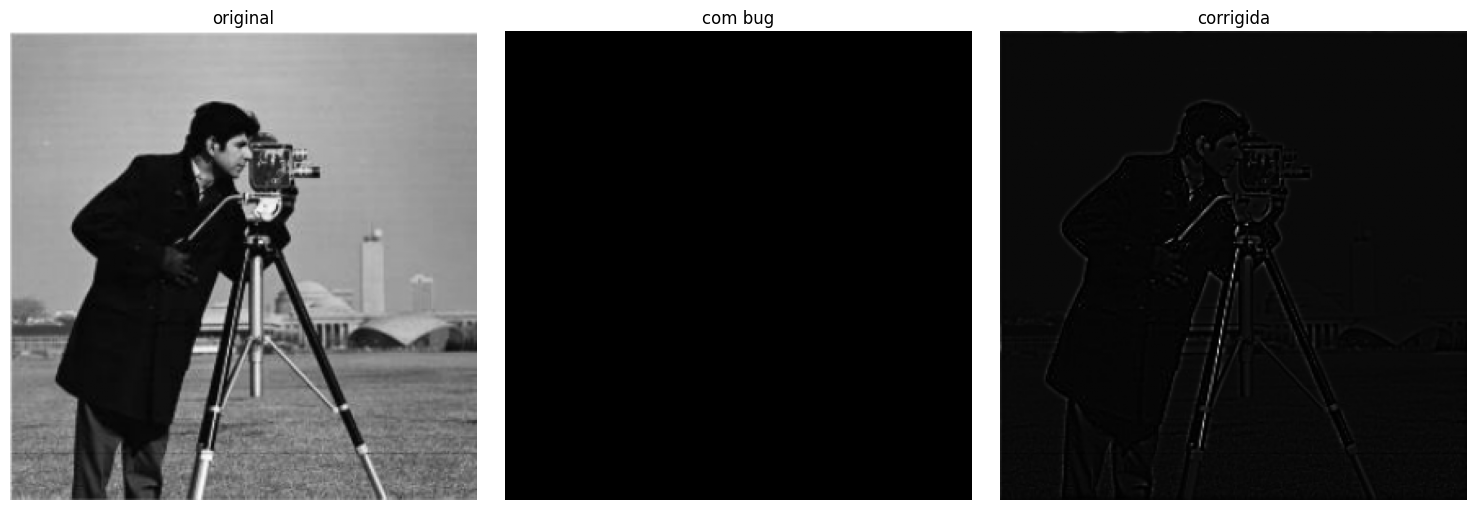

bug: tem inf/nan? True


In [22]:
# demonstra a diferenca entre a versao com bug e a corrigida usando a cameraman
cam_path = caminho_imagem("cameraman.png")  # caminho da imagem cameraman
saida_bug = homomorfico_bug(cam_path, 0.20, 2.5, 1.5, 60)  # resultado com os erros
saida_ok = homomorfico_corrigido(cam_path, 0.20, 2.5, 1.5, 60)  # resultado corrigido
# troca valores invalidos (inf/nan) por numeros finitos so para conseguir exibir
saida_bug_vis = np.nan_to_num(saida_bug, nan=0.0, posinf=0.0, neginf=0.0)  # limpa inf/nan

# painel comparando original, versao com bug e versao corrigida
fig, ax = plt.subplots(1, 3, figsize=(15, 5))  # tres eixos
ax[0].imshow(img_cameraman, cmap="gray"); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(normaliza_vis(saida_bug_vis), cmap="gray"); ax[1].set_title("com bug"); ax[1].axis("off")
ax[2].imshow(normaliza_vis(saida_ok), cmap="gray"); ax[2].set_title("corrigida"); ax[2].axis("off")
plt.tight_layout(); plt.show()  # exibe o painel
print("bug: tem inf/nan?", (not np.isfinite(saida_bug).all()))  # mostra que o bug gera valores invalidos


## Parte B: Filtragem homomórfica na prática (opcional, até +10 pts)

Fluxo: $f \to \ln(f+\epsilon) \to \text{FFT2} \to H\cdot G \to \text{IFFT2} \to \exp(\cdot)-\epsilon$, com $\epsilon=0{,}01$ e

$$H(u,v)=(\gamma_H-\gamma_L)\Big[1-e^{-c D^2/D_0^2}\Big]+\gamma_L$$

Imagens: `sailboat` (iluminação natural) e `cameraman` (forte diferença de brilho).

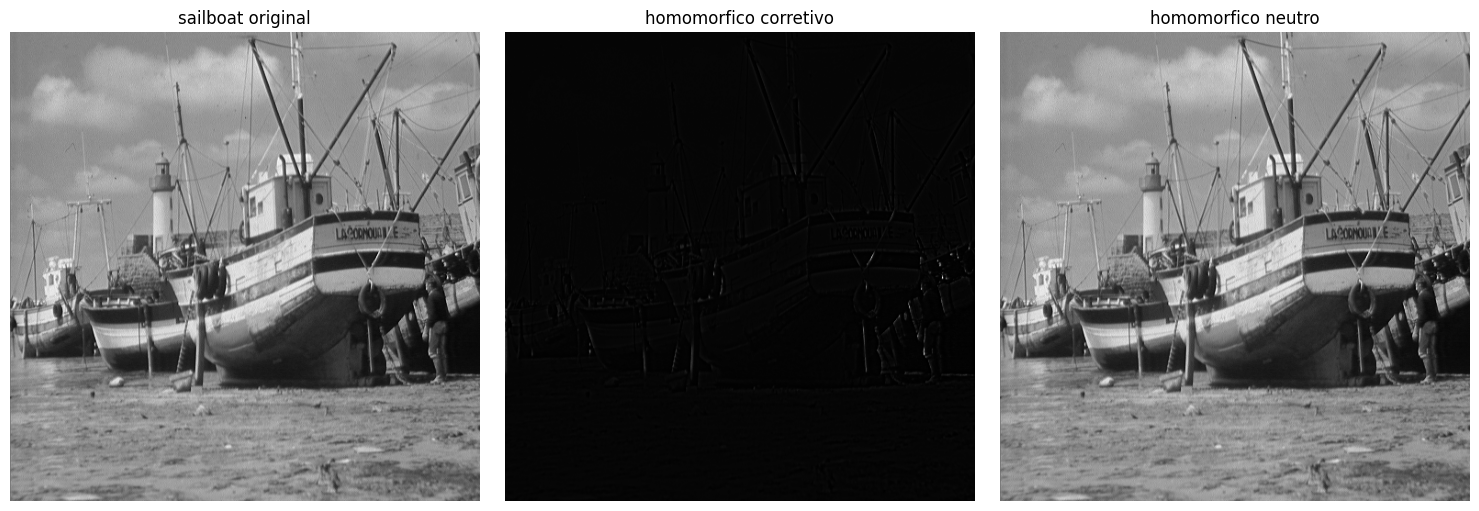

desvio maximo do caso neutro em relacao a identidade: 9.96425164601078e-13


In [23]:
# filtragem homomorfica operando direto sobre uma imagem em tons de cinza
def homomorfico_img(img_gray, gamma_l, gamma_h, c, d0, eps=0.01):
    Y = img_gray.astype(np.float64) / 255.0  # normaliza para [0,1]
    g = np.log(Y + eps)  # leva ao dominio log somando eps (trata pixel 0)
    G_uv = np.fft.fftshift(np.fft.fft2(g))  # fft centralizada
    D = grade_distancia(Y.shape)  # distancia ao centro (reusa a funcao da q3)
    H = (gamma_h - gamma_l) * (1 - np.exp(-c * (D ** 2) / (d0 ** 2))) + gamma_l  # filtro homomorfico
    S = H * G_uv  # aplica no espectro alinhado
    s = np.real(np.fft.ifft2(np.fft.ifftshift(S)))  # volta ao espaco
    out = np.exp(s) - eps  # desfaz o log
    return out, H

# dois conjuntos de parametros: corretivo e neutro (controle)
par_corretivo = dict(gamma_l=0.20, gamma_h=2.5, c=1.5, d0=60)  # realca detalhe e comprime iluminacao
par_neutro = dict(gamma_l=1.0, gamma_h=1.0, c=1.5, d0=60)  # H identicamente 1 (controle)

# aplica os dois conjuntos a sailboat e mostra com o caso neutro
out_corr, Hcorr = homomorfico_img(img_sailboat, **par_corretivo)  # resultado corretivo
out_neu, Hneu = homomorfico_img(img_sailboat, **par_neutro)  # resultado neutro
fig, ax = plt.subplots(1, 3, figsize=(15, 5))  # tres eixos
ax[0].imshow(img_sailboat, cmap="gray"); ax[0].set_title("sailboat original"); ax[0].axis("off")
ax[1].imshow(normaliza_vis(out_corr), cmap="gray"); ax[1].set_title("homomorfico corretivo"); ax[1].axis("off")
ax[2].imshow(normaliza_vis(out_neu), cmap="gray"); ax[2].set_title("homomorfico neutro"); ax[2].axis("off")
plt.tight_layout(); plt.show()  # exibe o painel
# mede o quanto o caso neutro difere da identidade (deve ser quase nulo)
dif_neutro = np.max(np.abs(normaliza_vis(out_neu) - normaliza_vis(img_sailboat.astype(np.float64))))
print("desvio maximo do caso neutro em relacao a identidade:", dif_neutro)


**Caso neutro (controle).** Com $\gamma_L=\gamma_H=1$ tem-se $H(u,v)\equiv 1$, ou seja, o filtro não altera o espectro. A saída deveria ser praticamente igual à entrada e qualquer pequena diferença revela apenas os artefatos numéricos do pipeline (ln/exp, o $\epsilon$ e o ponto flutuante), confirmado pelo desvio máximo próximo de zero impresso acima.

In [24]:
# unsharp masking (definicao usada tambem na q5); cv2 permitido so para o desfoque
def unsharp(img_gray, k=1.5, sigma=1.2):
    f = img_gray.astype(np.float64)  # imagem em float
    # unico uso de cv2 para processamento: desfoque gaussiano da mascara
    f_blur = cv2.GaussianBlur(f, (0, 0), sigmaX=sigma)  # versao suavizada
    return f + k * (f - f_blur)  # reforca as altas frequencias (bordas)

# entropia de shannon quantizando em 256 niveis
def entropia(img_gray):
    u = np.clip(img_gray, 0, 255).astype(np.uint8)  # garante faixa 0..255
    p = np.bincount(u.ravel(), minlength=256).astype(np.float64)  # contagem por nivel
    p = p / p.sum()  # converte para probabilidades
    p = p[p > 0]  # descarta niveis vazios para o log
    return -np.sum(p * np.log2(p))  # entropia em bits

# convolucao 2d em python puro com padding reflexivo (para o sobel manual)
def convolve2d_manual(img, kernel):
    k = kernel.shape[0]  # tamanho do kernel quadrado
    p = k // 2  # padding em cada lado
    ap = np.pad(img.astype(np.float64), p, mode="reflect")  # estende as bordas (operacao de array)
    out = np.zeros_like(img, dtype=np.float64)  # matriz de saida
    for i in range(k):  # percorre as linhas do kernel
        for j in range(k):  # percorre as colunas do kernel
            out += kernel[i, j] * ap[i:i + img.shape[0], j:j + img.shape[1]]  # soma deslocada
    return out

# gradiente medio usando os kernels de sobel implementados manualmente
def gradiente_medio(img_gray):
    sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)  # sobel em x
    sy = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)  # sobel em y
    gx = convolve2d_manual(img_gray, sx)  # derivada horizontal
    gy = convolve2d_manual(img_gray, sy)  # derivada vertical
    return np.sqrt(gx ** 2 + gy ** 2).mean()  # media da magnitude do gradiente

# contraste rms (desvio padrao das intensidades)
def contraste_rms(img_gray):
    return img_gray.astype(np.float64).std()  # espalhamento de contraste

# converte qualquer saida para uint8 0..255 recortando percentis extremos
def para_uint8(x):
    x = x.astype(np.float64)  # garante float
    # recorta os outliers de 0.5% e 99.5% (o exp do homomorfico gera picos isolados)
    lo, hi = np.percentile(x, 0.5), np.percentile(x, 99.5)  # limites robustos
    x = np.clip(x, lo, hi)  # remove os extremos que dominariam a escala
    x = (x - lo) / (hi - lo + 1e-12)  # reescala a faixa util para 0..1
    return (x * 255).astype(np.uint8)  # leva para 0..255


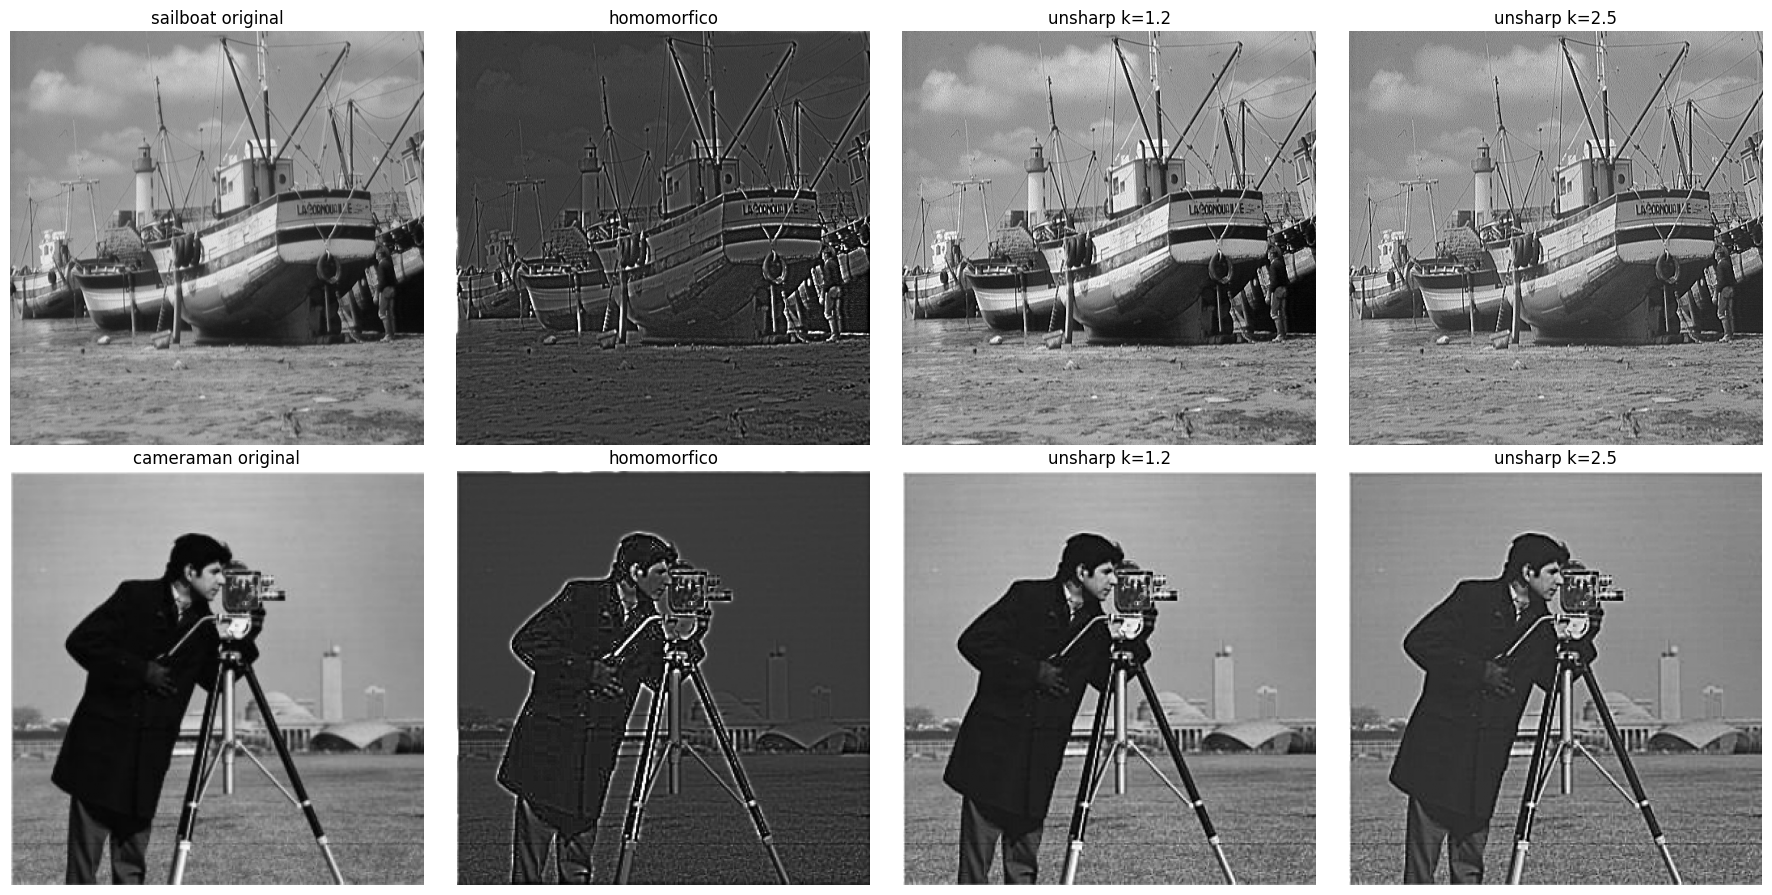

salvo q4b_metricas.csv
sailboat   original       entropia=7.191 grad=65.812 rms=46.68
sailboat   homomorfico    entropia=6.332 grad=90.512 rms=28.72
sailboat   unsharp k=1.2  entropia=7.433 grad=108.504 rms=53.06
sailboat   unsharp k=2.5  entropia=7.278 grad=116.415 rms=45.09
cameraman  original       entropia=7.090 grad=61.755 rms=62.01
cameraman  homomorfico    entropia=5.689 grad=79.488 rms=29.39
cameraman  unsharp k=1.2  entropia=7.084 grad=82.772 rms=56.22
cameraman  unsharp k=2.5  entropia=6.867 grad=87.406 rms=45.79


In [25]:
# compara homomorfico (corretivo) e unsharp (k=1.2 e k=2.5) nas duas imagens
imagens_b = {"sailboat": img_sailboat, "cameraman": img_cameraman}  # imagens da parte b
linhas_b = []  # acumula metricas para o csv
fig, ax = plt.subplots(2, 4, figsize=(18, 9))  # grade 2x4 (uma linha por imagem)
for r, (nome, im) in enumerate(imagens_b.items()):
    homo, _ = homomorfico_img(im, **par_corretivo)  # homomorfico corretivo
    homo_u = para_uint8(homo)  # versao 0..255 para metricas/exibicao
    uns12 = para_uint8(unsharp(im, k=1.2))  # unsharp k=1.2
    uns25 = para_uint8(unsharp(im, k=2.5))  # unsharp k=2.5
    # exibe original e os tres realces
    ax[r, 0].imshow(im, cmap="gray"); ax[r, 0].set_title(nome + " original"); ax[r, 0].axis("off")
    ax[r, 1].imshow(homo_u, cmap="gray"); ax[r, 1].set_title("homomorfico"); ax[r, 1].axis("off")
    ax[r, 2].imshow(uns12, cmap="gray"); ax[r, 2].set_title("unsharp k=1.2"); ax[r, 2].axis("off")
    ax[r, 3].imshow(uns25, cmap="gray"); ax[r, 3].set_title("unsharp k=2.5"); ax[r, 3].axis("off")
    # calcula metricas (entropia, gradiente medio, contraste rms) de cada resultado
    for met_nome, met_img in [("original", im), ("homomorfico", homo_u),
                              ("unsharp k=1.2", uns12), ("unsharp k=2.5", uns25)]:
        linhas_b.append([nome, met_nome, entropia(met_img), gradiente_medio(met_img), contraste_rms(met_img)])
plt.tight_layout(); plt.show()  # exibe o painel

# salva as metricas da parte b em csv
with open("q4b_metricas.csv", "w", newline="") as f:
    w = csv.writer(f)  # escritor csv
    w.writerow(["imagem", "metodo", "entropia_bits", "grad_medio", "contraste_rms"])  # cabecalho
    w.writerows(linhas_b)  # linhas de dados
print("salvo q4b_metricas.csv")  # confirma a gravacao
for l in linhas_b:  # imprime a tabela no console
    print("%-10s %-14s entropia=%.3f grad=%.3f rms=%.2f" % (l[0], l[1], l[2], l[3], l[4]))


**Comparação (Parte B).** O homomórfico atua sobre o modelo multiplicativo $f=i\cdot r$: comprime a iluminação (baixas frequências, $\gamma_L<1$) e realça a reflectância/detalhe (altas frequências, $\gamma_H>1$), equilibrando o brilho entre regiões claras e escuras, o que é ideal para a `cameraman` (forte diferença objeto/fundo). O unsharp realça bordas locais e aumenta bastante o gradiente médio, mas não corrige a iluminação desigual e amplifica ruído para $k$ alto. Em geral, para iluminação desigual o homomórfico se sai melhor perceptualmente, enquanto o unsharp vence quando o objetivo é apenas nitidez local. As métricas de entropia, gradiente e contraste RMS na tabela quantificam isso.

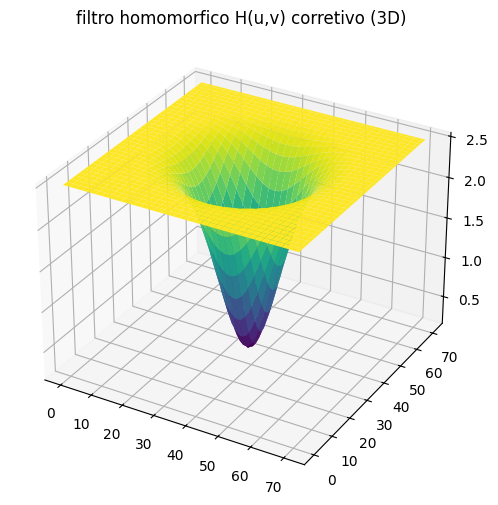

In [26]:
# visualiza o filtro H(u,v) homomorfico do conjunto corretivo em 3d
_, H_b = homomorfico_img(img_cameraman, **par_corretivo)  # recupera o filtro corretivo
passo = max(1, H_b.shape[0] // 64)  # subamostra a malha para ficar leve
Hsb = H_b[::passo, ::passo]  # filtro reduzido
yyb, xxb = np.indices(Hsb.shape)  # grade da malha
fig = plt.figure(figsize=(8, 6))  # figura 3d
ax3 = fig.add_subplot(projection="3d")  # eixo 3d
ax3.plot_surface(xxb, yyb, Hsb, cmap="viridis")  # superficie do filtro
ax3.set_title("filtro homomorfico H(u,v) corretivo (3D)"); plt.show()  # exibe


**Forma de $H(u,v)$ (Parte B).** O filtro vale $\gamma_L$ no centro (baixas frequências, iluminação) e tende a $\gamma_H$ nas bordas (altas frequências, detalhe). Aumentar $\gamma_H$ levanta o patamar alto (mais realce de detalhe); reduzir $\gamma_L$ aprofunda o vale central (mais compressão de iluminação); aumentar $D_0$ alarga a região de transição, deslocando para frequências mais altas o ponto onde o filtro deixa de comprimir e passa a realçar.

# Questão 5: Síntese, Robustez e Filtro Híbrido (15 pts)

Imagem: `boat` (cinza, referência, papel de `airplane2`). Integra os métodos das Questões 1 a 3.

## 5.1 Comparação sistemática (tabela salva em CSV)

O **PSNR só é significativo quando há referência limpa** (caso de restauração). Por isso aplicamos os métodos de suavização/notch à imagem corrompida da Q3 e comparamos com a original. Para métodos de **realce** (Gaussiano PA, unsharp, homomórfico), comparar com a original é frágil e o PSNR pode cair apesar da melhora visual, então deixamos a coluna PSNR como "n/a" e usamos contraste RMS, entropia e gradiente médio mais a discussão visual.

In [27]:
# monta a tabela comparativa de metodos sobre a boat
shape = img_boat.shape  # dimensoes
resultados = []  # acumula as linhas da tabela

# helper que mede o tempo medio de 5 execucoes de uma funcao
def tempo_medio_ms(func, repeticoes=5):
    t = []  # lista de tempos
    for _ in range(repeticoes):  # repete a medicao
        ini = time.perf_counter()  # marca o inicio
        func()  # executa a operacao
        t.append(time.perf_counter() - ini)  # acumula a duracao
    return 1000.0 * np.mean(t)  # devolve a media em milissegundos

# define cada metodo: (nome, funcao_de_saida, eh_restauracao)
# restauracao opera na imagem ruidosa e compara com a original (psnr valido)
# realce opera na imagem limpa e nao usa psnr
def m_pb():  # gaussiano passa-baixa (restauracao)
    return np.clip(aplica_filtro_freq(f_ruido, filtro_pb(shape, 80)), 0, 255)
def m_pa():  # gaussiano passa-alta (realce)
    return para_uint8(aplica_filtro_freq(f_orig, filtro_pa(shape, 30)))
def m_butter():  # butterworth passa-baixa (restauracao)
    return np.clip(aplica_filtro_freq(f_ruido, filtro_butterworth(shape, 50, 2)), 0, 255)
def m_notch():  # notch rejeita-faixa (restauracao)
    return np.clip(aplica_filtro_freq(f_ruido, H_notch), 0, 255)
def m_unsharp():  # unsharp masking (realce)
    return para_uint8(unsharp(f_orig, k=1.5, sigma=1.2))
def m_homo():  # homomorfico corretivo (realce)
    return para_uint8(homomorfico_img(f_orig, **par_corretivo)[0])

metodos_q5 = [
    ("Gaussiano PB", m_pb, True),       # restauracao
    ("Gaussiano PA", m_pa, False),      # realce
    ("Butterworth (opc.)", m_butter, True),  # restauracao
    ("Notch", m_notch, True),           # restauracao
    ("Unsharp Mask", m_unsharp, False), # realce
    ("Homomorfico (opc.)", m_homo, False),   # realce
]

# calcula as metricas e o tempo de cada metodo
for nome, func, eh_restauracao in metodos_q5:
    out = func()  # imagem resultante
    tms = tempo_medio_ms(func)  # tempo medio em ms
    # psnr so quando ha referencia limpa (restauracao)
    pval = ("%.2f" % psnr(f_orig, out)) if eh_restauracao else "n/a"
    resultados.append([nome, pval, "%.2f" % contraste_rms(out),
                       "%.3f" % entropia(out), "%.3f" % gradiente_medio(out), "%.2f" % tms])

# salva a tabela em csv
with open("q5_comparacao.csv", "w", newline="") as f:
    w = csv.writer(f)  # escritor csv
    w.writerow(["metodo", "psnr_db", "contraste_rms", "entropia_bits", "grad_medio", "tempo_ms"])  # cabecalho
    w.writerows(resultados)  # linhas
print("salvo q5_comparacao.csv\n")  # confirma

# imprime a tabela formatada
print("%-20s %-9s %-9s %-9s %-9s %-9s" % ("metodo", "psnr", "rms", "entropia", "grad", "tempo_ms"))
for r in resultados:
    print("%-20s %-9s %-9s %-9s %-9s %-9s" % tuple(r))


salvo q5_comparacao.csv

metodo               psnr      rms       entropia  grad      tempo_ms 
Gaussiano PB         14.11     53.71     7.346     199.564   27.71    
Gaussiano PA         n/a       22.64     5.550     59.766    38.63    
Butterworth (opc.)   16.36     43.15     7.371     132.804   32.02    
Notch                42.72     21.76     5.308     21.386    25.86    
Unsharp Mask         n/a       34.07     6.114     54.210    13.94    
Homomorfico (opc.)   n/a       20.66     5.075     46.476    46.00    


## 5.2 Custo computacional: domínio espacial vs frequência

Comparamos um método **espacial** (convolução manual de Sobel, custo teórico $O(N^2 k^2)$) e um método na **frequência** (Gaussiano PB via FFT, custo $O(N^2 \log N)$), medindo o tempo médio de 5 execuções em resoluções 256x256 e 512x512.

resolucao 256 -> espacial(sobel)=1.68 ms | frequencia(fft)=5.38 ms


resolucao 512 -> espacial(sobel)=20.78 ms | frequencia(fft)=31.48 ms


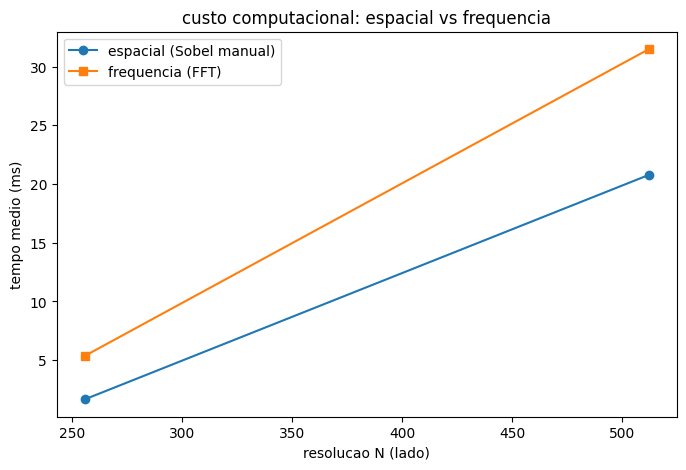

In [28]:
# prepara duas resolucoes: 256 (subamostrando a boat) e 512 (original)
res512 = img_boat  # 512x512
res256 = img_boat[::2, ::2]  # 256x256 por subamostragem (operacao numpy)
resolucoes = [("256", res256), ("512", res512)]  # lista de resolucoes

tempos_espacial = []  # tempos do metodo espacial (sobel manual)
tempos_freq = []  # tempos do metodo na frequencia (gaussiano pb)
for nome, im in resolucoes:
    # metodo espacial: convolucao manual de sobel
    te = tempo_medio_ms(lambda im=im: gradiente_medio(im))
    # metodo na frequencia: filtragem gaussiana passa-baixa via fft
    tf = tempo_medio_ms(lambda im=im: aplica_filtro_freq(im, filtro_pb(im.shape, 30)))
    tempos_espacial.append(te); tempos_freq.append(tf)  # acumula
    print("resolucao %s -> espacial(sobel)=%.2f ms | frequencia(fft)=%.2f ms" % (nome, te, tf))

# grafico tempo vs resolucao para os dois metodos
xs = [256, 512]  # eixo de resolucao
plt.figure(figsize=(8, 5))  # figura
plt.plot(xs, tempos_espacial, "o-", label="espacial (Sobel manual)")  # curva espacial
plt.plot(xs, tempos_freq, "s-", label="frequencia (FFT)")  # curva frequencia
plt.xlabel("resolucao N (lado)"); plt.ylabel("tempo medio (ms)")  # rotulos
plt.title("custo computacional: espacial vs frequencia"); plt.legend(); plt.show()  # exibe


**Discussão (5.2).** Teoricamente a convolução espacial custa $O(N^2 k^2)$ (depende do tamanho $k$ do kernel) e a filtragem na frequência custa $O(N^2\log N)$ (Seção 4.10). Para **kernels pequenos** (Sobel $3\times3$), $k^2$ é uma constante minúscula, então na prática a convolução espacial é $O(N^2)$ e pode ser **mais rápida** que a FFT, que paga o custo do $\log N$ e das duas transformadas (direta e inversa). O gráfico costuma mostrar exatamente esse contraste entre teoria e medição: a FFT só compensa quando o kernel equivalente é grande.

## 5.3 Filtro híbrido

Combinamos **homomórfico seguido de unsharp**: $g = \text{unsharp}\big(\text{homomorfico}(f)\big)$. O homomórfico equaliza a iluminação e realça detalhe global; o unsharp adiciona nitidez local nas bordas. Comparamos o híbrido com cada método isolado.

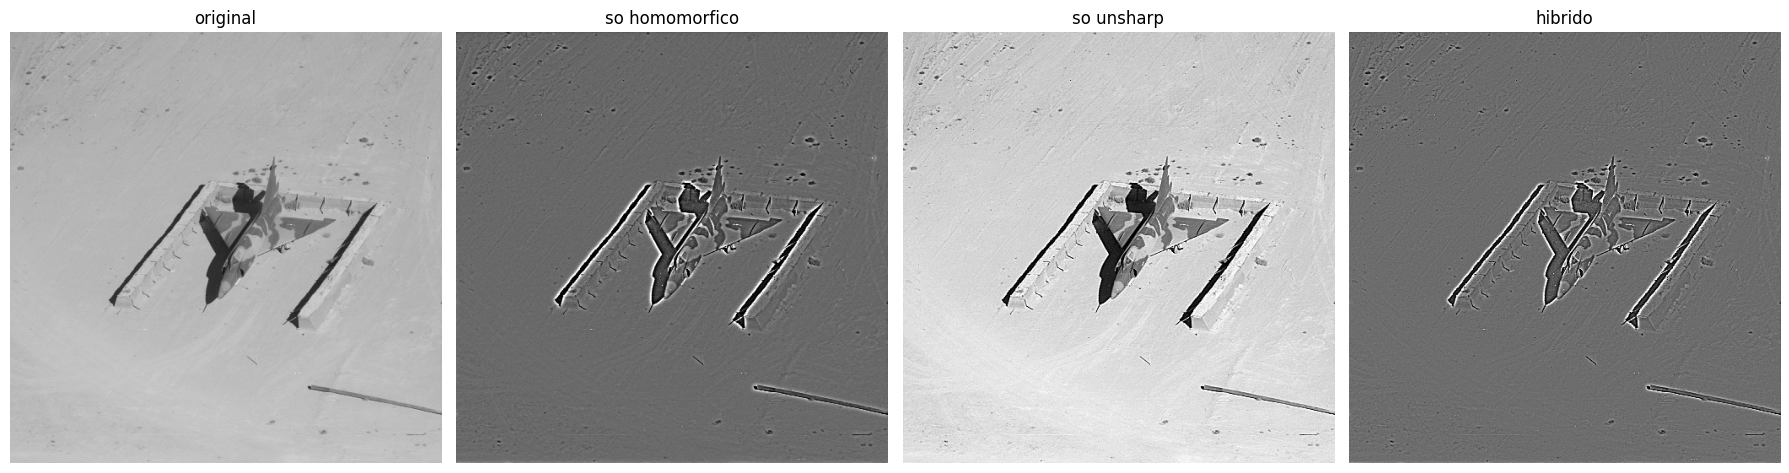

original     entropia=4.004 grad=21.395 rms=22.12
homomorfico  entropia=5.075 grad=46.476 rms=20.66
unsharp      entropia=6.114 grad=54.210 rms=34.07
hibrido      entropia=5.310 grad=55.338 rms=20.86


In [29]:
# filtro hibrido: homomorfico corretivo seguido de unsharp
homo_only = para_uint8(homomorfico_img(f_orig, **par_corretivo)[0])  # so homomorfico
unsharp_only = para_uint8(unsharp(f_orig, k=1.5, sigma=1.2))  # so unsharp
# hibrido: aplica unsharp sobre a saida homomorfica
hibrido_raw, _ = homomorfico_img(f_orig, **par_corretivo)  # passo 1: homomorfico
hibrido = para_uint8(unsharp(para_uint8(hibrido_raw), k=1.5, sigma=1.2))  # passo 2: unsharp

# painel comparando original, isolados e hibrido
fig, ax = plt.subplots(1, 4, figsize=(18, 5))  # quatro eixos
ax[0].imshow(img_boat, cmap="gray"); ax[0].set_title("original"); ax[0].axis("off")
ax[1].imshow(homo_only, cmap="gray"); ax[1].set_title("so homomorfico"); ax[1].axis("off")
ax[2].imshow(unsharp_only, cmap="gray"); ax[2].set_title("so unsharp"); ax[2].axis("off")
ax[3].imshow(hibrido, cmap="gray"); ax[3].set_title("hibrido"); ax[3].axis("off")
plt.tight_layout(); plt.show()  # exibe

# metricas dos tres para comparar
for nome, im in [("original", img_boat), ("homomorfico", homo_only),
                 ("unsharp", unsharp_only), ("hibrido", hibrido)]:
    print("%-12s entropia=%.3f grad=%.3f rms=%.2f" %
          (nome, entropia(im), gradiente_medio(im), contraste_rms(im)))


**Discussão (5.3).** O híbrido tende a apresentar o maior gradiente médio (mais nitidez) combinado com a iluminação equalizada do homomórfico, superando cada método isolado em realce de detalhe; o risco é amplificar ruído em excesso, por isso a escolha de $k$ e dos parâmetros homomórficos importa.

## 5.4 (Aprof.) Sensibilidade paramétrica

Variamos o $k$ do unsharp de 0,5 a 3,0 e observamos entropia e contraste RMS (métricas adequadas a realce; PSNR não se aplica por não haver referência limpa nesse caso).

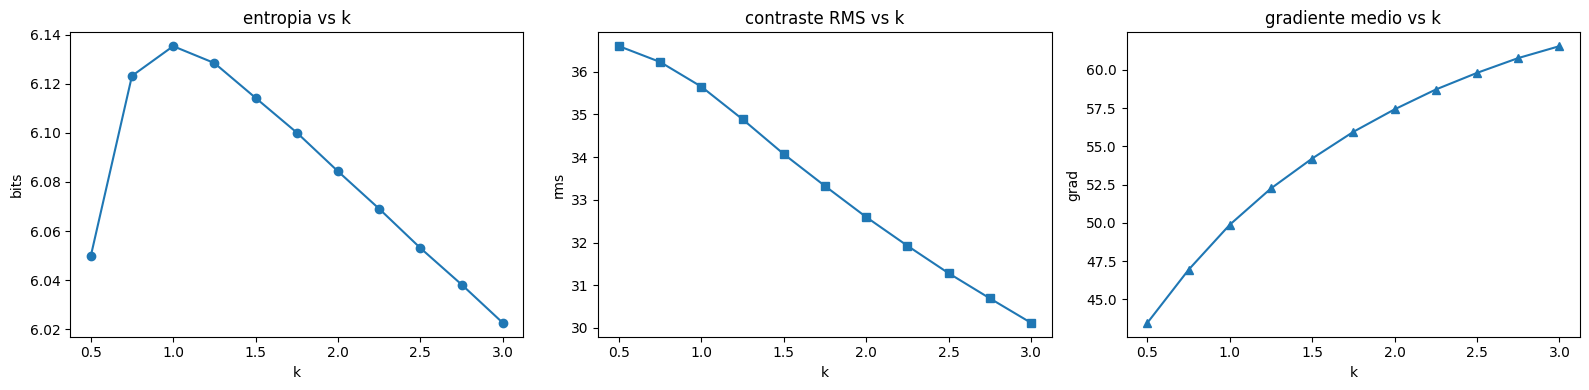

In [30]:
# varredura do parametro k do unsharp e seu efeito nas metricas de realce
ks = np.arange(0.5, 3.01, 0.25)  # valores de k de 0.5 a 3.0
ent_vals = []  # entropia por k
rms_vals = []  # contraste rms por k
grad_vals = []  # gradiente medio por k
for k in ks:
    out = para_uint8(unsharp(f_orig, k=k, sigma=1.2))  # aplica o unsharp com esse k
    ent_vals.append(entropia(out))  # mede entropia
    rms_vals.append(contraste_rms(out))  # mede contraste rms
    grad_vals.append(gradiente_medio(out))  # mede gradiente medio

# graficos das metricas em funcao de k
fig, ax = plt.subplots(1, 3, figsize=(16, 4))  # tres eixos
ax[0].plot(ks, ent_vals, "o-"); ax[0].set_title("entropia vs k"); ax[0].set_xlabel("k"); ax[0].set_ylabel("bits")
ax[1].plot(ks, rms_vals, "s-"); ax[1].set_title("contraste RMS vs k"); ax[1].set_xlabel("k"); ax[1].set_ylabel("rms")
ax[2].plot(ks, grad_vals, "^-"); ax[2].set_title("gradiente medio vs k"); ax[2].set_xlabel("k"); ax[2].set_ylabel("grad")
plt.tight_layout(); plt.show()  # exibe


**Discussão (5.4).** Conforme $k$ cresce, o contraste RMS e o gradiente médio aumentam de forma quase monotônica (mais realce), mas a entropia tende a saturar ou cair quando o realce é exagerado e começa a saturar pixels (clipping). Isso mostra que existe uma faixa útil de $k$: passar dela degrada a imagem em vez de melhorar. Quando a imagem tem regiões muito diferentes (iluminação desigual), um $k$ fixo não serve para tudo, justificando **métodos adaptativos** (parâmetros que variam localmente).

# Diário de bordo

**(i) O que mais me confundiu.** O alinhamento entre o filtro centrado e o espectro: foi preciso entender bem onde fica a frequência zero para usar `fftshift`/`ifftshift` na ordem certa, o que só ficou claro depois de ver o efeito do desalinhamento na Q4.

**(ii) Algo que tentei e não funcionou (e por quê).** Tentei somar o ruído periódico direto na imagem uint8; ocorreu overflow/wrap-around (valores estouravam 255 e davam a volta), o que corrompia o espectro; a solução foi converter para float antes de somar e só depois aplicar clip e voltar para uint8.

**(iii) Algo que me surpreendeu.** A reconstrução só com a fase já revela a estrutura da cena, enquanto a reconstrução só com a magnitude vira um borrão: ficou claro que a fase carrega a informação de posição das bordas, sendo perceptualmente mais importante que a magnitude.